In [1]:
### read the json file fleet_kincadeFire/Ladris_example/Forecast.geojson
import json
import geopandas as gpd
import matplotlib.pyplot as plt

with open('fleet_kincadeFire/Ladris_example/37hr_2dest/Forecast.geojson') as f:
    data = json.load(f)

### print the keys of data
print(data.keys())

dict_keys(['type', 'features', 'properties'])


In [2]:
### Redwood is 101
### CA 12 is 12
### Gravenstein is 116


### for each feature in data['features']
for feature in data['features']:
    ### check if 'properties' 'Name' has 101 in it
    if 'Gravenstein' in feature['properties']['Name']:
        ### print the feature
        print(feature)
    #else:
    #    print(feature['properties']['Name'])

{'type': 'Feature', 'geometry': {'type': 'LineString', 'coordinates': [[-122.7202669, 38.3322262], [-122.7198903, 38.3321769]]}, 'properties': {'GUID': 28887105, 'Name': 'Gravenstein Highway', 'Lane Count': 1, 'Length (m)': 33, 'congestionLevel': 4, 'congestion_percentage_by_time': [[5355, 0], [10710, 0], [16065, 0], [21421, 0], [26776, 0], [32131, 0], [37487, 0], [42842, 97], [48197, 97], [53553, 97], [58908, 97], [64263, 97], [69618, 97], [74974, 97], [80329, 97], [85684, 97], [91040, 97], [96395, 97], [101750, 97], [107106, 97], [112461, 97], [117816, 0], [123171, 0], [128527, 0], [133882, 0]]}}
{'type': 'Feature', 'geometry': {'type': 'LineString', 'coordinates': [[-122.818132, 38.3929617], [-122.8180944, 38.392903], [-122.8180642, 38.3928461]]}, 'properties': {'GUID': 28750041, 'Name': 'Gravenstein Highway', 'Lane Count': 1, 'Length (m)': 14, 'congestionLevel': 4, 'congestion_percentage_by_time': [[5355, 0], [10710, 0], [16065, 0], [21421, 0], [26776, 97], [32131, 97], [37487, 97]

In [3]:
### create a geopandas dataframe that contains GUID, Name, congestion_percentage_by_time, and geometry LineString
ladris_gdf = gpd.GeoDataFrame.from_features(data['features'])
ladris_gdf = ladris_gdf[['GUID', 'Name', 'congestion_percentage_by_time', 'geometry']]
ladris_gdf = ladris_gdf.set_crs(epsg=4326)
ladris_gdf.head()

,GUID,Name,congestion_percentage_by_time,geometry
0,28793424,Day Road,"[[5355, 0], [10710, 96], [16065, 96], [21421, ...","LINESTRING (-122.80749 38.52301, -122.8075 38...."
1,28795004,Ventura Avenue,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.72435 38.46447, -122.72435 38..."
2,28894311,Northpoint Parkway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.74231 38.41578, -122.74225 38..."
3,28918323,Grove Street,"[[5355, 0], [10710, 97], [16065, 97], [21421, ...","LINESTRING (-122.87577 38.62291, -122.87577 38..."
4,28796826,Fulton Road,"[[5355, 97], [10710, 97], [16065, 97], [21421,...","LINESTRING (-122.76947 38.51575, -122.76958 38..."


In [4]:
### read fleet_kincadeFire/Ladris_example/kincade_road_network/guid_speed.csv and store the first column as a key and the second column as a value in a dictionary
guid_speed = {}
with open('fleet_kincadeFire/Ladris_example/kincade_road_network/guid_speed.csv') as f:
    for line in f:
        key, value = line.strip().split(',')
        guid_speed[int(key)] = float(value)  
print(len(guid_speed))

218569


In [5]:
### for each row of ladris_gdf map the GUID to guid_speed and store it in a new column called speed
ladris_gdf['speed'] = ladris_gdf['GUID'].map(guid_speed)
ladris_gdf.head()



,GUID,Name,congestion_percentage_by_time,geometry,speed
0,28793424,Day Road,"[[5355, 0], [10710, 96], [16065, 96], [21421, ...","LINESTRING (-122.80749 38.52301, -122.8075 38....",27.0
1,28795004,Ventura Avenue,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.72435 38.46447, -122.72435 38...",40.0
2,28894311,Northpoint Parkway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.74231 38.41578, -122.74225 38...",40.0
3,28918323,Grove Street,"[[5355, 0], [10710, 97], [16065, 97], [21421, ...","LINESTRING (-122.87577 38.62291, -122.87577 38...",40.0
4,28796826,Fulton Road,"[[5355, 97], [10710, 97], [16065, 97], [21421,...","LINESTRING (-122.76947 38.51575, -122.76958 38...",40.0


# Process Ladris output data and get travel time per segment

In [6]:
import pandas as pd
data = pd.read_csv('PRJ-3226/Highway_Vehicle_Routing_Data_R1.csv')

In [7]:
data.head()

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY
0,User1,38.434102,-122.696106,1571302260000,38.360030,-122.505948,1571303700000,Hwy 12,Hwy 12
1,User1,38.429124,-122.563283,1571618820000,38.535854,-122.799232,1571627580000,Hwy 12,Hwy 101
2,User1,38.462512,-122.644908,1571932920000,38.455989,-122.627828,1571939340000,Hwy 12,Hwy 12
3,User2,38.582761,-122.840816,1571268060000,38.467404,-122.728035,1571269320000,Hwy 101,Hwy 101
4,User2,38.233902,-122.618472,1571665500000,38.193047,-122.600319,1571666640000,Hwy 101,Hwy 101


In [8]:
### convert Entrance_TIMESTAMP and Exit_TIMESTAMP to datetime
### convert Entrance_TIMESTAMP and Exit_TIMESTAMP from milliseconds to datetime
data['Entrance_TIMESTAMP'] = pd.to_datetime(data['Entrance_TIMESTAMP'], unit='ms')
data['Exit_TIMESTAMP'] = pd.to_datetime(data['Exit_TIMESTAMP'], unit='ms')
data['Travel_Time'] = (data['Exit_TIMESTAMP'] - data['Entrance_TIMESTAMP']).dt.total_seconds() / 60  # Convert to minutes 
data.head()

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time
0,User1,38.434102,-122.696106,2019-10-17 08:51:00,38.360030,-122.505948,2019-10-17 09:15:00,Hwy 12,Hwy 12,24.0
1,User1,38.429124,-122.563283,2019-10-21 00:47:00,38.535854,-122.799232,2019-10-21 03:13:00,Hwy 12,Hwy 101,146.0
2,User1,38.462512,-122.644908,2019-10-24 16:02:00,38.455989,-122.627828,2019-10-24 17:49:00,Hwy 12,Hwy 12,107.0
3,User2,38.582761,-122.840816,2019-10-16 23:21:00,38.467404,-122.728035,2019-10-16 23:42:00,Hwy 101,Hwy 101,21.0
4,User2,38.233902,-122.618472,2019-10-21 13:45:00,38.193047,-122.600319,2019-10-21 14:04:00,Hwy 101,Hwy 101,19.0


In [9]:
import numpy as np
### add a column for distance that calculates the distance between to Lat Long points using Haversine formula
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # radius of Earth in meters
    phi_1 = np.radians(lat1)
    phi_2 = np.radians(lat2)

    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi / 2.0) ** 2 + np.cos(phi_1) * np.cos(phi_2) * np.sin(delta_lambda / 2.0) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    meters = R * c  # output distance in meters
    ### convert meters to miles
    meters = meters * 0.000621371
    return meters

data['Distance'] = data.apply(lambda x: haversine(x['Entrance_LAT'], x['Entrance_LON'], x['Exit_LAT'], x['Exit_LON']), axis=1)
### calculate average speed in mph
data['Avg_Speed'] = data['Distance'] / (data['Travel_Time'] / 60)
data.head()

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time,Distance,Avg_Speed
0,User1,38.434102,-122.696106,2019-10-17 08:51:00,38.360030,-122.505948,2019-10-17 09:15:00,Hwy 12,Hwy 12,24.0,11.498809,28.747023
1,User1,38.429124,-122.563283,2019-10-21 00:47:00,38.535854,-122.799232,2019-10-21 03:13:00,Hwy 12,Hwy 101,146.0,14.738999,6.057123
2,User1,38.462512,-122.644908,2019-10-24 16:02:00,38.455989,-122.627828,2019-10-24 17:49:00,Hwy 12,Hwy 12,107.0,1.028137,0.576526
3,User2,38.582761,-122.840816,2019-10-16 23:21:00,38.467404,-122.728035,2019-10-16 23:42:00,Hwy 101,Hwy 101,21.0,10.034531,28.670089
4,User2,38.233902,-122.618472,2019-10-21 13:45:00,38.193047,-122.600319,2019-10-21 14:04:00,Hwy 101,Hwy 101,19.0,2.989884,9.441740


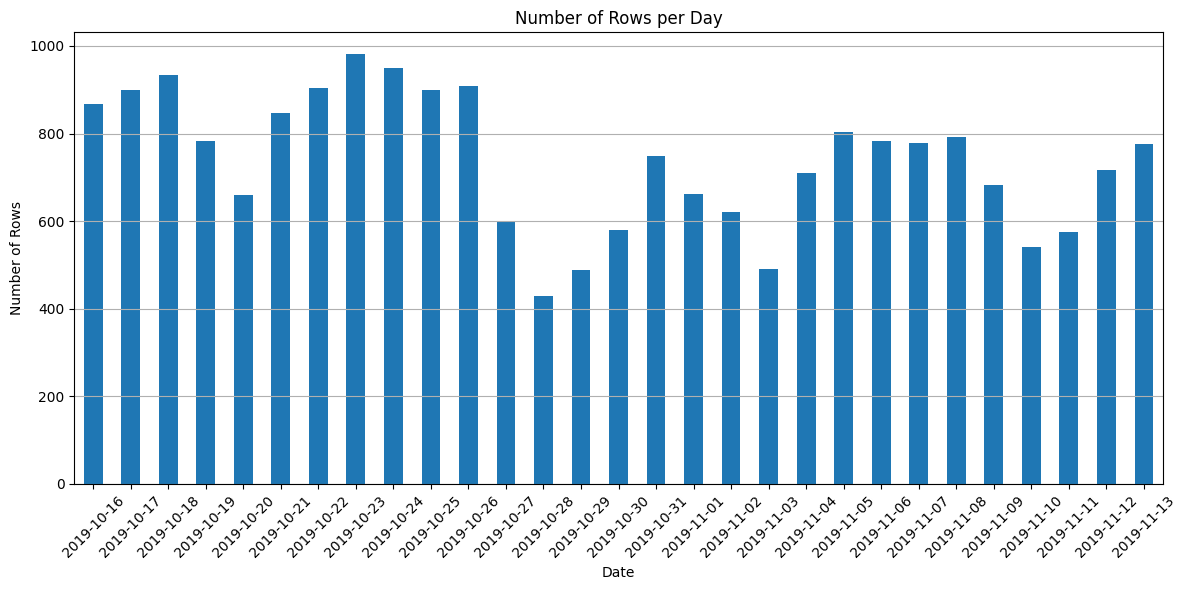

In [10]:
### plot the numer of rows per day
data['Date'] = data['Entrance_TIMESTAMP'].dt.date
daily_counts = data['Date'].value_counts().sort_index()
daily_counts.plot(kind='bar', figsize=(12, 6))
plt.title('Number of Rows per Day')
plt.xlabel('Date')
plt.ylabel('Number of Rows')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

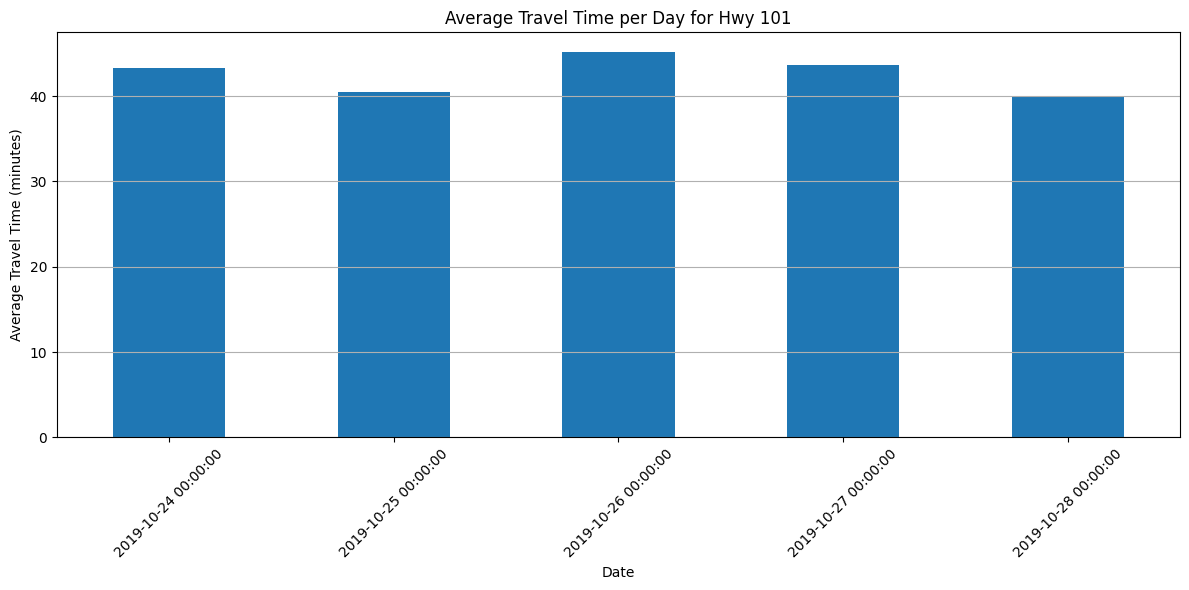

In [11]:
### calculate the average travel time per day for october 24,25,26,27 for rows with Entrance_HWY or Exit_HWY is Hwy 101
avg_travel_time = data[data['Entrance_HWY'] == 'Hwy 101'].groupby('Date')['Travel_Time'].mean()
avg_travel_time = avg_travel_time.reindex(pd.date_range(start='2019-10-24', end='2019-10-28'), fill_value=0)
avg_travel_time.plot(kind='bar', figsize=(12, 6))
plt.title('Average Travel Time per Day for Hwy 101')
plt.xlabel('Date')
plt.ylabel('Average Travel Time (minutes)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


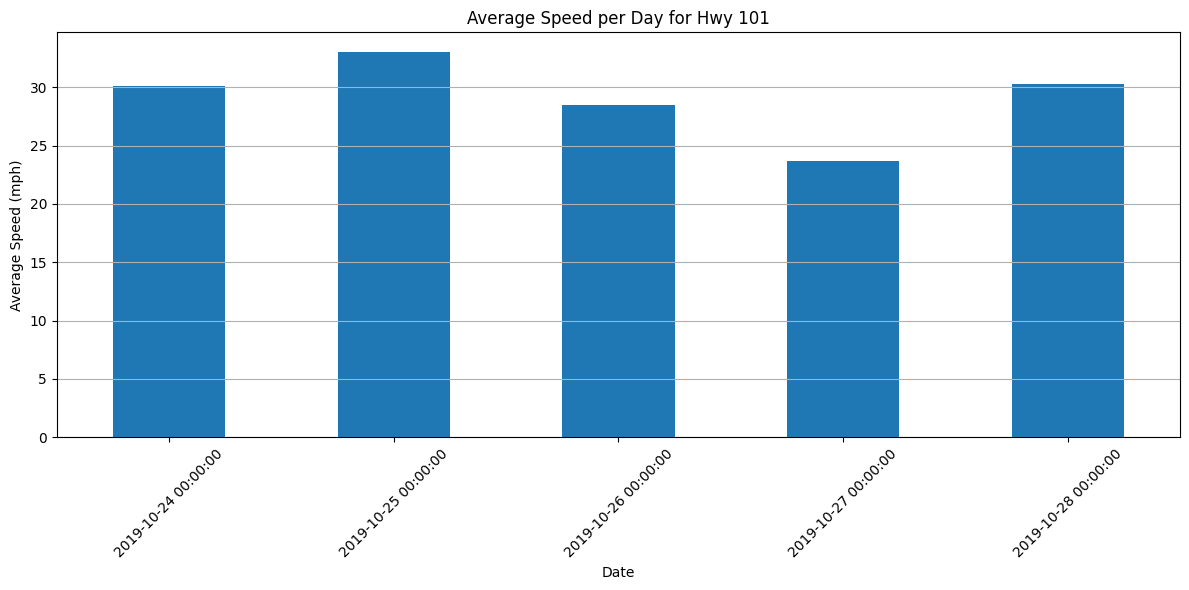

In [12]:
### calculate the average speed per day for october 24,25,26,27, 28 for rows with Entrance_HWY or Exit_HWY is Hwy 101
avg_speed = data[data['Entrance_HWY'] == 'Hwy 101'].groupby('Date')['Avg_Speed'].mean()
avg_speed = avg_speed.reindex(pd.date_range(start='2019-10-24', end='2019-10-28'), fill_value=0)
avg_speed.plot(kind='bar', figsize=(12, 6))
plt.title('Average Speed per Day for Hwy 101')
plt.xlabel('Date')
plt.ylabel('Average Speed (mph)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

/tmp/ipykernel_44011/294996950.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Hour'] = filtered_data['Entrance_TIMESTAMP'].dt.floor('H')


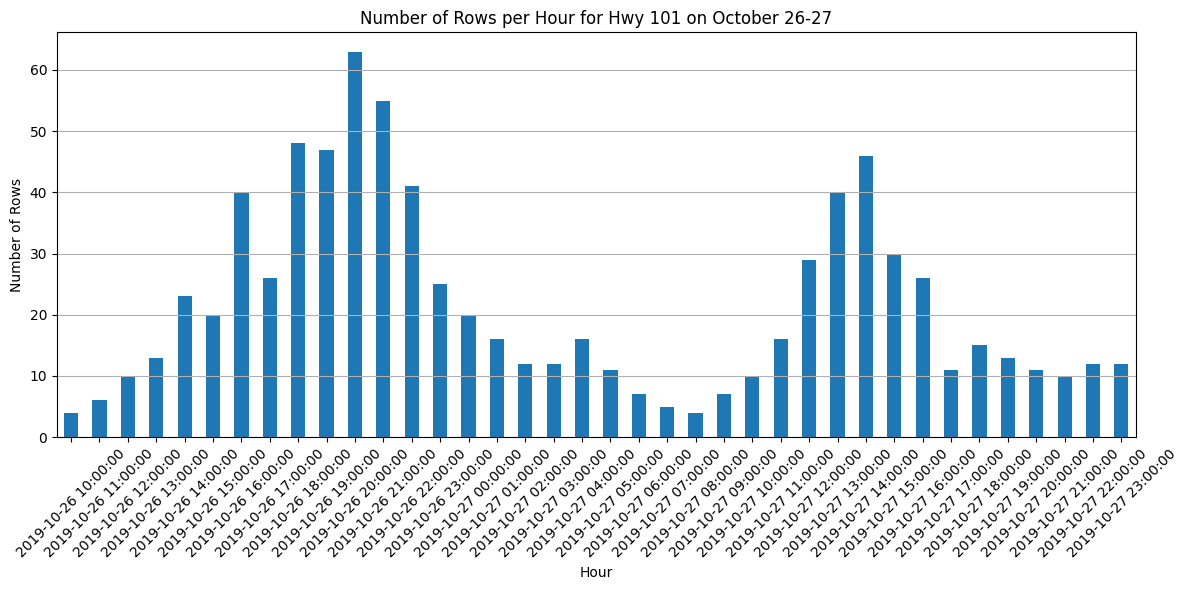

In [13]:
### for October 26 from 10am to October 27 plot the number of rows per hour for Entrance_HWY or Exit_HWY is Hwy 101
import matplotlib.pyplot as plt
# Filter data for October 26 from 10am to October 27
filtered_data = data[(data['Entrance_TIMESTAMP'] >= '2019-10-26 10:00:00') & (data['Entrance_TIMESTAMP'] < '2019-10-28 00:00:00') & (data['Entrance_HWY'] == 'Hwy 101')]
filtered_data['Hour'] = filtered_data['Entrance_TIMESTAMP'].dt.floor('H')
hourly_counts = filtered_data['Hour'].value_counts().sort_index()
hourly_counts.plot(kind='bar', figsize=(12, 6))
plt.title('Number of Rows per Hour for Hwy 101 on October 26-27')
plt.xlabel('Hour')
plt.ylabel('Number of Rows')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [14]:
ladris_gdf.head()

,GUID,Name,congestion_percentage_by_time,geometry,speed
0,28793424,Day Road,"[[5355, 0], [10710, 96], [16065, 96], [21421, ...","LINESTRING (-122.80749 38.52301, -122.8075 38....",27.0
1,28795004,Ventura Avenue,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.72435 38.46447, -122.72435 38...",40.0
2,28894311,Northpoint Parkway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.74231 38.41578, -122.74225 38...",40.0
3,28918323,Grove Street,"[[5355, 0], [10710, 97], [16065, 97], [21421, ...","LINESTRING (-122.87577 38.62291, -122.87577 38...",40.0
4,28796826,Fulton Road,"[[5355, 97], [10710, 97], [16065, 97], [21421,...","LINESTRING (-122.76947 38.51575, -122.76958 38...",40.0


In [15]:
### print the total number of hourly_counts
print(f"Total number of hourly counts: {len(hourly_counts)}")
print(f"Total number of rows in data: {len(data)}")
print(f"Total number of unique dates: {data['Date'].nunique()}")
print(f"Total number of unique segments: {len(ladris_gdf)}")
print(f"Total number of unique segment IDs in segments_df: {ladris_gdf['GUID'].nunique()}")
print(f"Total number of unique link IDs in segments_df: {ladris_gdf['Name'].nunique()}")
print(f"Total number of unique link names in segments_df: {ladris_gdf['Name'].nunique()}")

### print the sum of the hourly_counts count values
print(f"Sum of hourly counts: {hourly_counts.sum()}")

Total number of hourly counts: 38
Total number of rows in data: 21413
Total number of unique dates: 29
Total number of unique segments: 18280
Total number of unique segment IDs in segments_df: 18280
Total number of unique link IDs in segments_df: 1412
Total number of unique link names in segments_df: 1412
Sum of hourly counts: 812


In [16]:
### print unique names of highways in data
unique_highways = data['Entrance_HWY'].unique()
print(f"Unique highways in data: {unique_highways}")

Unique highways in data: ['Hwy 12' 'Hwy 101' 'Hwy 37' 'Hwy 128' 'Hwy 116' 'Hwy 1']


In [17]:
### Redwood is 101
### CA 12 is 12
### Gravenstein is 116

### Reduce unique_highways to only 'Hwy 12', 'Hwy 101', and 'Hwy 116'
unique_highways = ['Hwy 12', 'Hwy 101', 'Hwy 116']

/tmp/ipykernel_44011/3144618622.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Hour'] = filtered_data['Entrance_TIMESTAMP'].dt.floor('H')


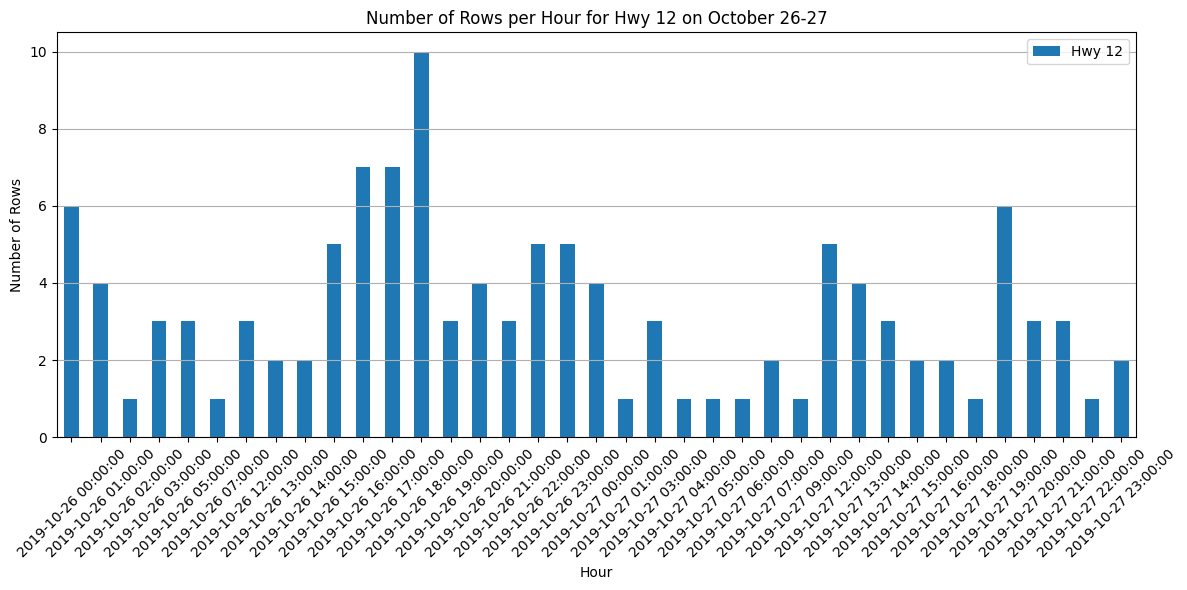

/tmp/ipykernel_44011/3144618622.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Hour'] = filtered_data['Entrance_TIMESTAMP'].dt.floor('H')


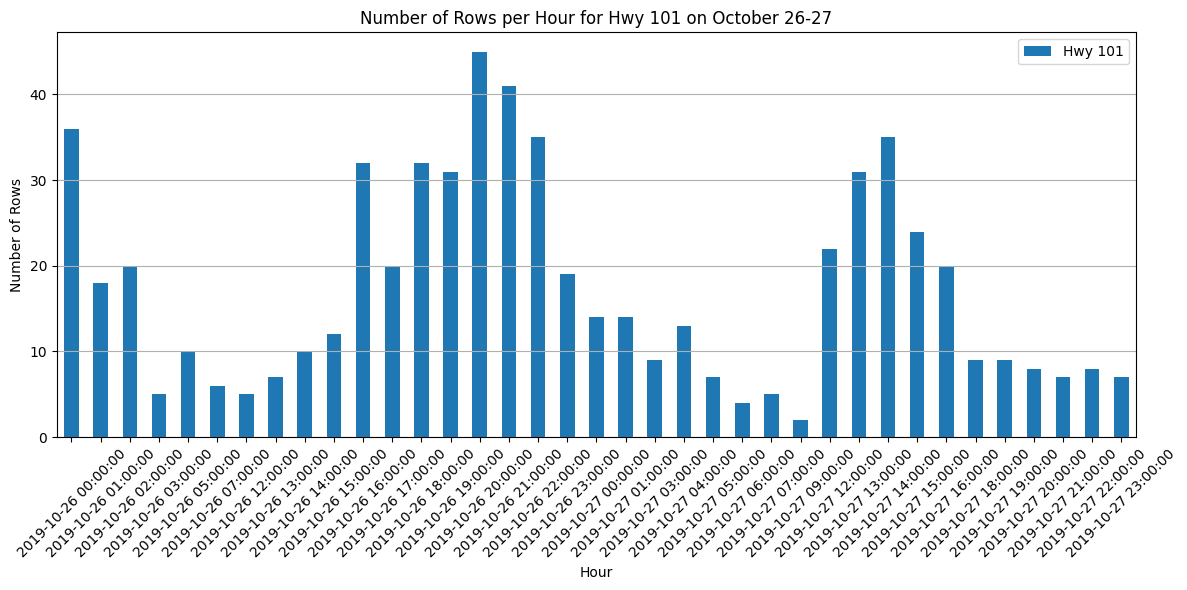

/tmp/ipykernel_44011/3144618622.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Hour'] = filtered_data['Entrance_TIMESTAMP'].dt.floor('H')


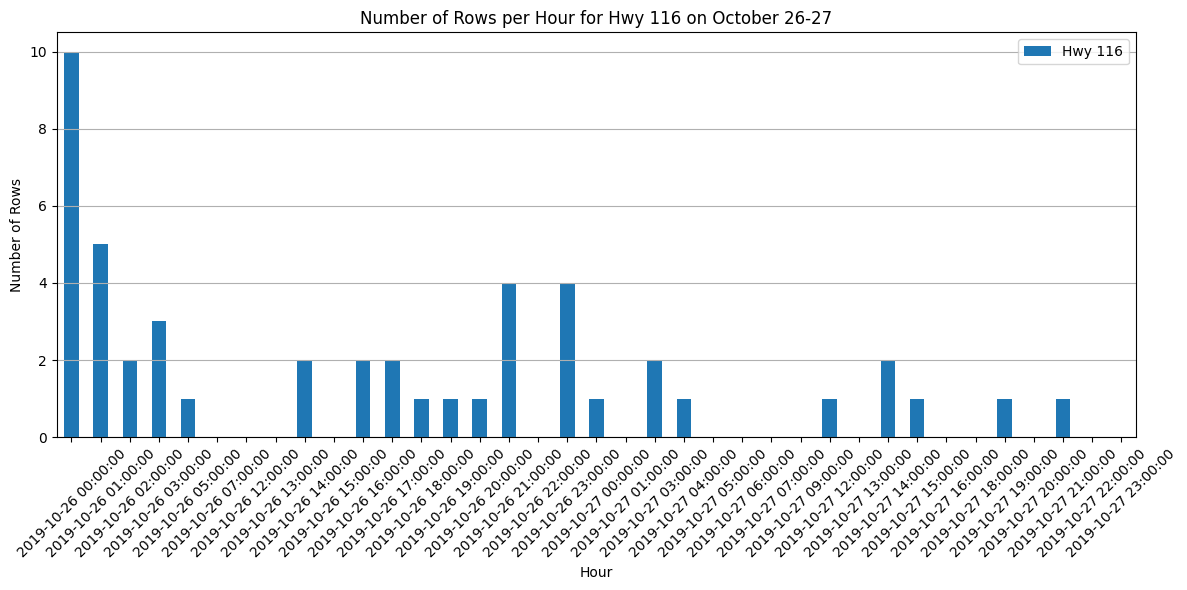

In [18]:
### for October 26 from 10am to October 27 plot the number of rows per hour for Entrance_HWY or Exit_HWY is one of the unique highways
total_hourly_counts = pd.Series(dtype=int)
total_filtered_data = pd.DataFrame()
for highway in unique_highways:
    filtered_data = data[(data['Entrance_TIMESTAMP'] >= '2019-10-26 00:00:00') & (data['Entrance_TIMESTAMP'] < '2019-10-28 00:00:00') & (data['Entrance_HWY'] == highway) & (data['Exit_HWY'] == highway)] 
    filtered_data['Hour'] = filtered_data['Entrance_TIMESTAMP'].dt.floor('H')
    
    hourly_counts = filtered_data['Hour'].value_counts().sort_index()
    
    total_filtered_data = pd.concat([total_filtered_data, filtered_data], ignore_index=True)

    ### add the hourly_counts to total_hourly_counts
    if total_hourly_counts.empty:
        total_hourly_counts = hourly_counts
    else:
        # Align indices and fill missing values with 0
        hourly_counts = hourly_counts.reindex(total_hourly_counts.index, fill_value=0)
        # Add the counts
        total_hourly_counts += hourly_counts    
    
    if not hourly_counts.empty:
        hourly_counts.plot(kind='bar', figsize=(12, 6), label=highway)
        plt.title(f'Number of Rows per Hour for {highway} on October 26-27')
        plt.xlabel('Hour')
        plt.ylabel('Number of Rows')
        plt.xticks(rotation=45)
        plt.grid(axis='y')
        plt.legend()
        plt.tight_layout()
        plt.show()
        

In [19]:
print(len(total_hourly_counts))
total_hourly_counts

37


Hour
2019-10-26 00:00:00    52
2019-10-26 01:00:00    27
2019-10-26 02:00:00    23
2019-10-26 03:00:00    11
2019-10-26 05:00:00    14
2019-10-26 07:00:00     7
2019-10-26 12:00:00     8
2019-10-26 13:00:00     9
2019-10-26 14:00:00    14
2019-10-26 15:00:00    17
2019-10-26 16:00:00    41
2019-10-26 17:00:00    29
2019-10-26 18:00:00    43
2019-10-26 19:00:00    35
2019-10-26 20:00:00    50
2019-10-26 21:00:00    48
2019-10-26 22:00:00    40
2019-10-26 23:00:00    28
2019-10-27 00:00:00    19
2019-10-27 01:00:00    15
2019-10-27 03:00:00    14
2019-10-27 04:00:00    15
2019-10-27 05:00:00     8
2019-10-27 06:00:00     5
2019-10-27 07:00:00     7
2019-10-27 09:00:00     3
2019-10-27 12:00:00    28
2019-10-27 13:00:00    35
2019-10-27 14:00:00    40
2019-10-27 15:00:00    27
2019-10-27 16:00:00    22
2019-10-27 18:00:00    10
2019-10-27 19:00:00    16
2019-10-27 20:00:00    11
2019-10-27 21:00:00    11
2019-10-27 22:00:00     9
2019-10-27 23:00:00     9
Name: count, dtype: int64

In [20]:
### sum the values of total_hourly_counts
print(f"Sum of total hourly counts: {total_hourly_counts.sum()}")
print(f"Total number of unique hours: {total_hourly_counts.index.nunique()}")

Sum of total hourly counts: 800
Total number of unique hours: 37


In [21]:
filtered_data

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time,Distance,Avg_Speed,Date,Hour
862,User93,38.356640,-122.768290,2019-10-26 14:38:00,38.334538,-122.739408,2019-10-26 15:04:00,Hwy 116,Hwy 116,26.0,2.186665,5.046150,2019-10-26,2019-10-26 14:00:00
1133,User111,38.490364,-122.961022,2019-10-26 16:20:00,38.468949,-123.012478,2019-10-26 17:03:00,Hwy 116,Hwy 116,43.0,3.152034,4.398188,2019-10-26,2019-10-26 16:00:00
1702,User182,38.466374,-122.882316,2019-10-26 17:45:00,38.450710,-122.867553,2019-10-26 17:58:00,Hwy 116,Hwy 116,13.0,1.345105,6.208178,2019-10-26,2019-10-26 17:00:00
1750,User184,38.424060,-122.847254,2019-10-26 23:37:00,38.345954,-122.759706,2019-10-26 23:52:00,Hwy 116,Hwy 116,15.0,7.183690,28.734759,2019-10-26,2019-10-26 23:00:00
2746,User308,38.405692,-122.837126,2019-10-26 00:48:00,38.352220,-122.765200,2019-10-26 01:00:00,Hwy 116,Hwy 116,12.0,5.369064,26.845322,2019-10-26,2019-10-26 00:00:00
2747,User308,38.333680,-122.731468,2019-10-26 04:36:00,38.423631,-122.847254,2019-10-26 04:51:00,Hwy 116,Hwy 116,15.0,8.829334,35.317337,2019-10-26,2019-10-26 04:00:00
2860,User324,38.425476,-122.848241,2019-10-26 00:31:00,38.472983,-123.016426,2019-10-26 01:15:00,Hwy 116,Hwy 116,44.0,9.674525,13.192534,2019-10-26,2019-10-26 00:00:00
2966,User342,38.494398,-123.009903,2019-10-26 02:12:00,38.379085,-122.798416,2019-10-26 03:21:00,Hwy 116,Hwy 116,69.0,13.945759,12.126747,2019-10-26,2019-10-26 02:00:00
2967,User342,38.379085,-122.798416,2019-10-26 03:30:00,38.502380,-122.995269,2019-10-26 06:59:00,Hwy 116,Hwy 116,209.0,13.640420,3.915910,2019-10-26,2019-10-26 03:00:00
2968,User342,38.494355,-123.009903,2019-10-26 09:12:00,38.379085,-122.798416,2019-10-26 10:22:00,Hwy 116,Hwy 116,70.0,13.944065,11.952056,2019-10-26,2019-10-26 09:00:00


In [22]:
### Summarize filtered_data
filtered_data['Hour'] = filtered_data['Entrance_TIMESTAMP'].dt.floor('H')
summary = filtered_data.groupby('Hour').agg({
    'Entrance_HWY': 'count',
    'Exit_HWY': 'count',
    'Travel_Time': 'mean',
    'Avg_Speed': 'mean'
}).rename(columns={
    'Entrance_HWY': 'Entrance_Count',
    'Exit_HWY': 'Exit_Count',
    'Travel_Time': 'Average_Travel_Time',
    'Avg_Speed': 'Average_Speed'
})
print(summary.head())

                     Entrance_Count  Exit_Count  Average_Travel_Time  \
Hour                                                                   
2019-10-26 00:00:00              10          10            18.100000   
2019-10-26 01:00:00               5           5            18.200000   
2019-10-26 02:00:00               2           2            45.000000   
2019-10-26 03:00:00               3           3            88.000000   
2019-10-26 04:00:00               3           3            18.666667   

                     Average_Speed  
Hour                                
2019-10-26 00:00:00      21.879771  
2019-10-26 01:00:00      16.337447  
2019-10-26 02:00:00      12.152470  
2019-10-26 03:00:00      18.918759  
2019-10-26 04:00:00      23.086174  


/tmp/ipykernel_44011/1986848991.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Hour'] = filtered_data['Entrance_TIMESTAMP'].dt.floor('H')


In [23]:
summary

,Entrance_Count,Exit_Count,Average_Travel_Time,Average_Speed
Hour,,,,
2019-10-26 00:00:00,10,10,18.100000,21.879771
2019-10-26 01:00:00,5,5,18.200000,16.337447
2019-10-26 02:00:00,2,2,45.000000,12.152470
2019-10-26 03:00:00,3,3,88.000000,18.918759
2019-10-26 04:00:00,3,3,18.666667,23.086174
2019-10-26 05:00:00,1,1,10.000000,31.533977
2019-10-26 09:00:00,1,1,70.000000,11.952056
2019-10-26 14:00:00,2,2,26.000000,11.004054
2019-10-26 16:00:00,2,2,26.500000,13.460703


In [24]:
total_filtered_data

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time,Distance,Avg_Speed,Date,Hour
0,User37,38.307287,-122.478139,2019-10-26 17:37:00,38.294198,-122.475950,2019-10-26 17:58:00,Hwy 12,Hwy 12,21.0,0.912118,2.606051,2019-10-26,2019-10-26 17:00:00
1,User98,38.319046,-122.485520,2019-10-26 20:25:00,38.302395,-122.475478,2019-10-26 20:35:00,Hwy 12,Hwy 12,10.0,1.272787,7.636719,2019-10-26,2019-10-26 20:00:00
2,User108,38.343465,-122.497494,2019-10-26 01:36:00,38.458950,-122.673962,2019-10-26 01:55:00,Hwy 12,Hwy 12,19.0,12.448713,39.311727,2019-10-26,2019-10-26 01:00:00
3,User108,38.449852,-122.683446,2019-10-26 05:12:00,38.392817,-122.530753,2019-10-26 05:26:00,Hwy 12,Hwy 12,14.0,9.156916,39.243925,2019-10-26,2019-10-26 05:00:00
4,User108,38.305785,-122.477710,2019-10-26 23:14:00,38.355610,-122.502558,2019-10-26 23:32:00,Hwy 12,Hwy 12,18.0,3.696630,12.322099,2019-10-26,2019-10-26 23:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,User2028,38.392002,-122.817728,2019-10-26 03:15:00,38.468563,-122.884547,2019-10-26 03:26:00,Hwy 116,Hwy 116,11.0,6.407988,34.952660,2019-10-26,2019-10-26 03:00:00
872,User2156,38.389170,-122.815711,2019-10-26 00:32:00,38.412086,-122.842662,2019-10-26 00:43:00,Hwy 116,Hwy 116,11.0,2.153280,11.745163,2019-10-26,2019-10-26 00:00:00
873,User2170,38.345782,-122.759535,2019-10-26 21:35:00,38.334367,-122.736961,2019-10-26 23:13:00,Hwy 116,Hwy 116,98.0,1.455552,0.891154,2019-10-26,2019-10-26 21:00:00
874,User2321,38.415091,-122.845280,2019-10-26 23:33:00,38.340804,-122.753055,2019-10-26 23:48:00,Hwy 116,Hwy 116,15.0,7.162274,28.649095,2019-10-26,2019-10-26 23:00:00


In [25]:
### Can I randomly split the total_filtered_data into two parts, one for training and one for testing?
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(total_filtered_data, test_size=0.2, random_state=42)
print(f"Training data size: {len(train_data)}")
print(f"Testing data size: {len(test_data)}")
print(f"Total data size: {len(total_filtered_data)}")
print(f"Total number of unique highways in training data: {train_data['Entrance_HWY'].nunique()}")
print(f"Total number of unique highways in testing data: {test_data['Entrance_HWY'].nunique()}")
print(f"Total number of unique highways in total data: {total_filtered_data['Entrance_HWY'].nunique()}")
print(f"Total number of unique segment IDs in total data: {total_filtered_data['Entrance_HWY'].nunique()}")
print(f"Total number of unique segment IDs in segments_df: {ladris_gdf['GUID'].nunique()}")
print(f"Total number of unique link IDs in segments_df: {ladris_gdf['Name'].nunique()}")
print(f"Total number of unique link names in segments_df: {ladris_gdf['Name'].nunique()}") 

Training data size: 700
Testing data size: 176
Total data size: 876
Total number of unique highways in training data: 3
Total number of unique highways in testing data: 3
Total number of unique highways in total data: 3
Total number of unique segment IDs in total data: 3
Total number of unique segment IDs in segments_df: 18280
Total number of unique link IDs in segments_df: 1412
Total number of unique link names in segments_df: 1412


In [26]:
### How much of training data and testing data have Entrance_HWY == Exit_HWY?
train_entrance_exit_match = train_data[train_data['Entrance_HWY'] == train_data['Exit_HWY']]
test_entrance_exit_match = test_data[test_data['Entrance_HWY'] == test_data['Exit_HWY']]
print(f"Training data with Entrance_HWY == Exit_HWY: {len(train_entrance_exit_match)}")
print(f"Testing data with Entrance_HWY == Exit_HWY: {len(test_entrance_exit_match)}")
print(f"Total training data size: {len(train_data)}")
print(f"Total testing data size: {len(test_data)}")
print(f"Total data size: {len(total_filtered_data)}")   

Training data with Entrance_HWY == Exit_HWY: 700
Testing data with Entrance_HWY == Exit_HWY: 176
Total training data size: 700
Total testing data size: 176
Total data size: 876


In [27]:
### convert segments_df[segments_df['linkName']=='US-101']['freeflowSpeed'] to integers
ladris_gdf.head()

,GUID,Name,congestion_percentage_by_time,geometry,speed
0,28793424,Day Road,"[[5355, 0], [10710, 96], [16065, 96], [21421, ...","LINESTRING (-122.80749 38.52301, -122.8075 38....",27.0
1,28795004,Ventura Avenue,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.72435 38.46447, -122.72435 38...",40.0
2,28894311,Northpoint Parkway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.74231 38.41578, -122.74225 38...",40.0
3,28918323,Grove Street,"[[5355, 0], [10710, 97], [16065, 97], [21421, ...","LINESTRING (-122.87577 38.62291, -122.87577 38...",40.0
4,28796826,Fulton Road,"[[5355, 97], [10710, 97], [16065, 97], [21421,...","LINESTRING (-122.76947 38.51575, -122.76958 38...",40.0


In [28]:
### pring ladris_gdf where Redwood is in Name
ladris_gdf[ladris_gdf['Name'].str.contains('Gravenstein Highway', na=False)]

,GUID,Name,congestion_percentage_by_time,geometry,speed
98,28887105,Gravenstein Highway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.72027 38.33223, -122.71989 38...",49.0
379,28750041,Gravenstein Highway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.81813 38.39296, -122.81809 38...",49.0
462,28726286,Gravenstein Highway South,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.78951 38.37304, -122.78806 38...",49.0
500,28740326,Gravenstein Highway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.75237 38.34049, -122.75118 38...",49.0
580,28852781,Gravenstein Highway North,"[[5355, 0], [10710, 0], [16065, 0], [21421, 90...","LINESTRING (-122.87608 38.4603, -122.8745 38.4...",49.0
...,...,...,...,...,...
18140,28749032,Gravenstein Highway North,"[[5355, 0], [10710, 0], [16065, 97], [21421, 9...","LINESTRING (-122.85722 38.43559, -122.85721 38...",49.0
18210,28726293,Gravenstein Highway South,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.78397 38.36898, -122.78386 38...",49.0
18217,28726258,Gravenstein Highway South,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.79403 38.37627, -122.7931 38....",49.0
18241,28748866,Gravenstein Highway North,"[[5355, 0], [10710, 0], [16065, 0], [21421, 97...","LINESTRING (-122.84614 38.42209, -122.84613 38...",49.0


In [29]:
### Redwood is 101
### CA 12 is 12
### Gravenstein is 116

### get rows of ladris_gdf where column Name contains '101'
### get segment ID for ladris_gdf[ladris_gdf['Name']=='US-101']['GUID']
ladris_hw101_segments = ladris_gdf[ladris_gdf['Name'] == 'Redwood Highway']
ladris_hw116_segments = ladris_gdf[ladris_gdf['Name'] == 'Gravenstein Highway']
ladris_hw12_segments = ladris_gdf[ladris_gdf['Name'] == 'CA 12']
print(len(ladris_hw101_segments), len(ladris_hw116_segments), len(ladris_hw12_segments))


50 79 13


In [30]:
### get total_data['speed'] for each segment in fleet_hw101_segments
ladris_speed_hw101 = {}
ladris_speed_hw116 = {}
ladris_speed_hw12 = {}
for seg_id in ladris_hw101_segments['GUID']:
    if seg_id in ladris_gdf['GUID'].values:
        seg_data = ladris_gdf[ladris_gdf['GUID'] == seg_id]
        ladris_speed_hw101[seg_id] = seg_data['speed'].values[0]
for seg_id in ladris_hw116_segments['GUID']:
    if seg_id in ladris_gdf['GUID'].values:
        seg_data = ladris_gdf[ladris_gdf['GUID'] == seg_id]
        ladris_speed_hw116[seg_id] = seg_data['speed'].values[0]
for seg_id in ladris_hw12_segments['GUID']:
    if seg_id in ladris_gdf['GUID'].values:
        seg_data = ladris_gdf[ladris_gdf['GUID'] == seg_id]
        ladris_speed_hw12[seg_id] = seg_data['speed'].values[0]




In [31]:
print(len(ladris_speed_hw101), len(ladris_speed_hw116), len(ladris_speed_hw12))

50 79 13


In [32]:
ladris_gdf.head()

,GUID,Name,congestion_percentage_by_time,geometry,speed
0,28793424,Day Road,"[[5355, 0], [10710, 96], [16065, 96], [21421, ...","LINESTRING (-122.80749 38.52301, -122.8075 38....",27.0
1,28795004,Ventura Avenue,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.72435 38.46447, -122.72435 38...",40.0
2,28894311,Northpoint Parkway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.74231 38.41578, -122.74225 38...",40.0
3,28918323,Grove Street,"[[5355, 0], [10710, 97], [16065, 97], [21421, ...","LINESTRING (-122.87577 38.62291, -122.87577 38...",40.0
4,28796826,Fulton Road,"[[5355, 97], [10710, 97], [16065, 97], [21421,...","LINESTRING (-122.76947 38.51575, -122.76958 38...",40.0


In [33]:
### create a dictionary that maps GUID as the key and congestion_percentage_by_time as the value for ladris_gdf
ladris_congestion = {}
for index, row in ladris_gdf.iterrows():
    ladris_congestion[row['GUID']] = row['congestion_percentage_by_time']

print(len(ladris_congestion))

18280


In [34]:
ladris_congestion[28857930]

[[5355, 98],
 [10710, 98],
 [16065, 98],
 [21421, 98],
 [26776, 98],
 [32131, 98],
 [37487, 98],
 [42842, 98],
 [48197, 98],
 [53553, 98],
 [58908, 98],
 [64263, 98],
 [69618, 98],
 [74974, 98],
 [80329, 0],
 [85684, 0],
 [91040, 0],
 [96395, 0],
 [101750, 0],
 [107106, 0],
 [112461, 0],
 [117816, 0],
 [123171, 0],
 [128527, 0],
 [133882, 0]]

In [35]:
example_times = ladris_congestion[28857930]
### convert example_times to hours
example_times = [[int(time[0] / 6759), time[1]] for time in example_times]
example_times

[[0, 98],
 [1, 98],
 [2, 98],
 [3, 98],
 [3, 98],
 [4, 98],
 [5, 98],
 [6, 98],
 [7, 98],
 [7, 98],
 [8, 98],
 [9, 98],
 [10, 98],
 [11, 98],
 [11, 0],
 [12, 0],
 [13, 0],
 [14, 0],
 [15, 0],
 [15, 0],
 [16, 0],
 [17, 0],
 [18, 0],
 [19, 0],
 [19, 0]]

In [36]:
len(example_times)

25

In [37]:
### print first 5 values of fleet_speed_hw101
ladris_speed_hw101.keys()

dict_keys([28857931, 28857930, 28798888, 28836281, 28916791, 28892614, 28836283, 28884919, 28896726, 28795090, 28800206, 28799967, 28919550, 28798891, 28798892, 28838193, 28780003, 28780769, 28799378, 28798890, 28884911, 28781391, 28895853, 28780001, 28846299, 28874256, 28784994, 28784932, 28782942, 28827199, 28770235, 28846331, 28884343, 28783981, 28857928, 28855562, 28799549, 28884259, 28904760, 28799329, 28884102, 28770044, 28783980, 28801154, 28835052, 28769856, 28782940, 28801101, 28895425, 28855561])

In [38]:
print(len(ladris_speed_hw101), len(ladris_speed_hw116), len(ladris_speed_hw12))

50 79 13


# Calculate the simulated speeds per road segment of hw101 per time segment in hours from Ladris

In [39]:
ladrisInterpolation = 93

In [40]:
hw101_ladris_speed_congestion = {}
for seg_id in ladris_speed_hw101.keys():
    #seg_id = 28857930

    example_times = ladris_congestion[seg_id]
    ### convert example_times to hours
    #example_times = [[int(time[0] / 6759), time[1]] for time in example_times]
    ### set example_times as the integer count from 1 to the length of
    example_times = [[i + 1, time[1]] for i, time in enumerate(example_times)]

    ### example_times is a list of lists where each list is two values a time interval and a congestion level per time interval for seg_id which is a segment ID on hw101
    ### ladris_speed_hw101 is a dictionary that has the speed limit data for all segments on hw101 where the key is the segment ID and the value is the speed limit
    ### create a new example_congestion that computes for each time segment speed = speed limit * (1 - congestion level / 100)
    example_congestion = []
    timeCounts = 1
    for time in example_times:
        time_interval = round((time[0]*ladrisInterpolation)/60)
        congestion_level = time[1]
        speed_limit = ladris_speed_hw101[seg_id]
        speed = speed_limit * (1 - congestion_level / 100)
        if time_interval > timeCounts:
            example_congestion.append((timeCounts, speed))
            timeCounts += 1
        example_congestion.append((time_interval, speed))
        timeCounts += 1
    hw101_ladris_speed_congestion[seg_id] = example_congestion

len(hw101_ladris_speed_congestion)



50

In [41]:
#ladris_speed_hw116

hw116_ladris_speed_congestion = {}
for seg_id in ladris_speed_hw116.keys():
    #seg_id = 28857930

    example_times = ladris_congestion[seg_id]
    ### convert example_times to hours
    #example_times = [[int(time[0] / 6759), time[1]] for time in example_times]
    example_times = [[i + 1, time[1]] for i, time in enumerate(example_times)]

    ### example_times is a list of lists where each list is two values a time interval and a congestion level per time interval for seg_id which is a segment ID on hw101
    ### ladris_speed_hw101 is a dictionary that has the speed limit data for all segments on hw101 where the key is the segment ID and the value is the speed limit
    ### create a new example_congestion that computes for each time segment speed = speed limit * (1 - congestion level / 100)
    example_congestion = []
    timeCounts = 1
    for time in example_times:
        time_interval = round((time[0]*ladrisInterpolation)/60) 
        congestion_level = time[1]
        speed_limit = ladris_speed_hw116[seg_id]
        speed = speed_limit * (1 - congestion_level / 100)
        if time_interval > timeCounts:
            example_congestion.append((timeCounts, speed))
            timeCounts += 1
        example_congestion.append((time_interval, speed))
        timeCounts += 1
    hw116_ladris_speed_congestion[seg_id] = example_congestion

len(hw116_ladris_speed_congestion)

79

In [42]:
example_congestion

[(1, 49.0),
 (2, 49.0),
 (3, 49.0),
 (4, 49.0),
 (5, 49.0),
 (6, 49.0),
 (7, 49.0),
 (8, 49.0),
 (9, 49.0),
 (10, 49.0),
 (11, 49.0),
 (12, 1.4700000000000013),
 (13, 1.4700000000000013),
 (14, 1.4700000000000013),
 (15, 1.4700000000000013),
 (16, 1.4700000000000013),
 (17, 1.4700000000000013),
 (18, 1.4700000000000013),
 (19, 1.4700000000000013),
 (20, 1.4700000000000013),
 (21, 1.4700000000000013),
 (22, 1.4700000000000013),
 (23, 1.4700000000000013),
 (24, 1.4700000000000013),
 (25, 1.4700000000000013),
 (26, 1.4700000000000013),
 (27, 1.4700000000000013),
 (28, 1.4700000000000013),
 (29, 1.4700000000000013),
 (30, 1.4700000000000013),
 (31, 1.4700000000000013),
 (32, 1.4700000000000013),
 (33, 1.4700000000000013),
 (34, 49.0),
 (35, 49.0),
 (36, 49.0),
 (37, 49.0),
 (38, 49.0),
 (39, 49.0)]

In [43]:
#ladris_speed_hw12

hw12_ladris_speed_congestion = {}
for seg_id in ladris_speed_hw12.keys():
    #seg_id = 28857930

    example_times = ladris_congestion[seg_id]
    ### convert example_times to hours
    #example_times = [[int(time[0] / 6759), time[1]] for time in example_times]
    example_times = [[i + 1, time[1]] for i, time in enumerate(example_times)]

    ### example_times is a list of lists where each list is two values a time interval and a congestion level per time interval for seg_id which is a segment ID on hw101
    ### ladris_speed_hw101 is a dictionary that has the speed limit data for all segments on hw101 where the key is the segment ID and the value is the speed limit
    ### create a new example_congestion that computes for each time segment speed = speed limit * (1 - congestion level / 100)
    example_congestion = []
    timeCounts = 1
    for time in example_times:
        time_interval = round((time[0]*ladrisInterpolation)/60)
        congestion_level = time[1]
        speed_limit = ladris_speed_hw12[seg_id]
        speed = speed_limit * (1 - congestion_level / 100)
        if time_interval > timeCounts:
            example_congestion.append((timeCounts, speed))
            timeCounts += 1
        example_congestion.append((time_interval, speed))
        timeCounts += 1
    hw12_ladris_speed_congestion[seg_id] = example_congestion

len(hw12_ladris_speed_congestion)

13

In [44]:
example_congestion

[(1, 59.0),
 (2, 59.0),
 (3, 59.0),
 (4, 59.0),
 (5, 59.0),
 (6, 59.0),
 (7, 59.0),
 (8, 59.0),
 (9, 59.0),
 (10, 59.0),
 (11, 59.0),
 (12, 59.0),
 (13, 59.0),
 (14, 59.0),
 (15, 59.0),
 (16, 59.0),
 (17, 59.0),
 (18, 59.0),
 (19, 59.0),
 (20, 17.110000000000003),
 (21, 8.260000000000002),
 (22, 8.260000000000002),
 (23, 8.260000000000002),
 (24, 5.309999999999998),
 (25, 5.309999999999998),
 (26, 4.719999999999998),
 (27, 2.950000000000003),
 (28, 2.950000000000003),
 (29, 3.540000000000003),
 (30, 8.260000000000002),
 (31, 8.260000000000002),
 (32, 59.0),
 (33, 59.0),
 (34, 59.0),
 (35, 59.0),
 (36, 59.0),
 (37, 59.0),
 (38, 59.0),
 (39, 59.0)]

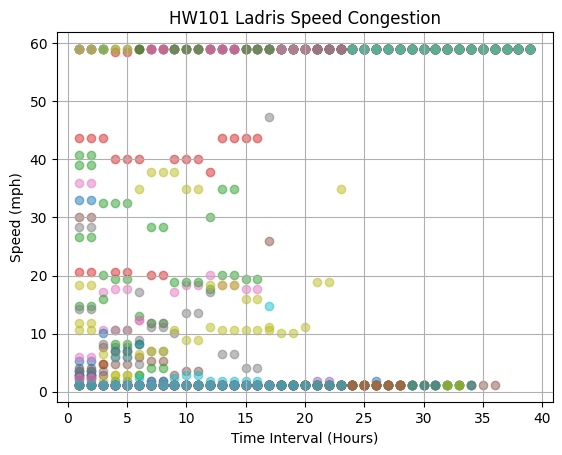

In [45]:
### Plot hw101_ladris_speed_congestion for all segments as scatter plot
for seg_id in hw101_ladris_speed_congestion.keys():
    times = [time[0] for time in hw101_ladris_speed_congestion[seg_id]]
    speeds = [time[1] for time in hw101_ladris_speed_congestion[seg_id]]
    plt.scatter(times, speeds, label=f'Segment {seg_id}', alpha=0.5)
plt.title('HW101 Ladris Speed Congestion')
plt.xlabel('Time Interval (Hours)')
plt.ylabel('Speed (mph)')
#plt.legend()
plt.grid()
plt.show()

In [46]:
for k in hw101_ladris_speed_congestion.keys():
    print(k, hw101_ladris_speed_congestion[k])

28857931 [(1, 2.950000000000003), (2, 2.950000000000003), (3, 1.180000000000001), (4, 1.180000000000001), (5, 1.180000000000001), (6, 1.180000000000001), (7, 1.180000000000001), (8, 1.180000000000001), (9, 1.180000000000001), (10, 1.180000000000001), (11, 1.180000000000001), (12, 1.180000000000001), (13, 1.180000000000001), (14, 1.180000000000001), (15, 1.180000000000001), (16, 1.180000000000001), (17, 1.180000000000001), (18, 1.180000000000001), (19, 1.180000000000001), (20, 1.180000000000001), (21, 1.180000000000001), (22, 1.180000000000001), (23, 1.180000000000001), (24, 59.0), (25, 59.0), (26, 59.0), (27, 59.0), (28, 59.0), (29, 59.0), (30, 59.0), (31, 59.0), (32, 59.0), (33, 59.0), (34, 59.0), (35, 59.0), (36, 59.0), (37, 59.0), (38, 59.0), (39, 59.0)]
28857930 [(1, 1.180000000000001), (2, 1.180000000000001), (3, 1.180000000000001), (4, 1.180000000000001), (5, 1.180000000000001), (6, 1.180000000000001), (7, 1.180000000000001), (8, 1.180000000000001), (9, 1.180000000000001), (10, 1

In [47]:
len(hw101_ladris_speed_congestion)

50

In [48]:
# hw101_ladris_speed_congestion[28782942]
### compute the average speed for each hour based on speed values from ladris_speed_congestion
### set hour_sum to be a list of 25 zeros

h101_total_count = len(hw101_ladris_speed_congestion)
hw101_hour_sum = [0] * h101_total_count
hw101_hour_avg = [0] * h101_total_count
hw101_hour_min = [60] * h101_total_count
for k in hw101_ladris_speed_congestion.keys():
    for time in hw101_ladris_speed_congestion[k]:
        hour = time[0]
        speed = time[1]
        hw101_hour_sum[hour-1] += speed
        if speed < hw101_hour_min[hour-1]:
            hw101_hour_min[hour-1] = speed
for i in range(h101_total_count):
    hw101_hour_avg[i] = hw101_hour_sum[i] / h101_total_count

hw101_hour_min

[1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 59.0,
 59.0,
 59.0,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60]

In [95]:
hw101_hour_avg

[15.741199999999987,
 15.741199999999987,
 10.407600000000002,
 8.472400000000002,
 8.472400000000002,
 10.218800000000003,
 9.640600000000003,
 9.640600000000003,
 11.882599999999998,
 11.906199999999997,
 11.906199999999997,
 11.009399999999996,
 11.009399999999996,
 11.009399999999996,
 11.375199999999998,
 11.375199999999998,
 14.820799999999986,
 18.702999999999985,
 18.702999999999985,
 22.195799999999995,
 25.8302,
 25.8302,
 30.762600000000003,
 34.7156,
 34.7156,
 38.196600000000004,
 42.81040000000001,
 42.81040000000001,
 48.5924,
 49.7488,
 49.7488,
 52.0616,
 52.0616,
 54.374399999999994,
 57.84360000000001,
 57.84360000000001,
 59.0,
 59.0,
 59.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [94]:
len(hw101_hour_min)

50

In [49]:
#hw101_ladris_speed_congestion[28782942]
hw101_hour_avg

[15.741199999999987,
 15.741199999999987,
 10.407600000000002,
 8.472400000000002,
 8.472400000000002,
 10.218800000000003,
 9.640600000000003,
 9.640600000000003,
 11.882599999999998,
 11.906199999999997,
 11.906199999999997,
 11.009399999999996,
 11.009399999999996,
 11.009399999999996,
 11.375199999999998,
 11.375199999999998,
 14.820799999999986,
 18.702999999999985,
 18.702999999999985,
 22.195799999999995,
 25.8302,
 25.8302,
 30.762600000000003,
 34.7156,
 34.7156,
 38.196600000000004,
 42.81040000000001,
 42.81040000000001,
 48.5924,
 49.7488,
 49.7488,
 52.0616,
 52.0616,
 54.374399999999994,
 57.84360000000001,
 57.84360000000001,
 59.0,
 59.0,
 59.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

# we now have list of average speeds per time with hw101_ladris_speed_congestion[28782942]

In [62]:
### compute the average speed for each hour based on speed values from ladris_speed_congestion
### set hour_sum to be a list of 25 zeros
hw116_hour_sum = [0] * h101_total_count
h116_total_count = len(hw116_ladris_speed_congestion)
hw116_hour_avg = [0] * h101_total_count
hw116_hour_min = [60] * h101_total_count
for k in hw116_ladris_speed_congestion.keys():
    for time in hw116_ladris_speed_congestion[k]:
        hour = time[0]
        speed = time[1]
        hw116_hour_sum[hour-1] += speed
        if speed < hw116_hour_min[hour-1]:
            hw116_hour_min[hour-1] = speed
for i in range(h101_total_count):
    hw116_hour_avg[i] = hw116_hour_sum[i] / h116_total_count

hw116_hour_min

[49.0,
 49.0,
 49.0,
 49.0,
 49.0,
 49.0,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 49.0,
 49.0,
 49.0,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60]

In [63]:
### compute the average speed for each hour based on speed values from ladris_speed_congestion
### set hour_sum to be a list of 25 zeros
hw12_hour_sum = [0] * h101_total_count
h12_total_count = len(hw12_ladris_speed_congestion)
hw12_hour_avg = [0] * h101_total_count
hw12_hour_min = [60] * h101_total_count
for k in hw12_ladris_speed_congestion.keys():
    for time in hw12_ladris_speed_congestion[k]:
        hour = time[0]
        speed = time[1]
        hw12_hour_sum[hour-1] += speed
        if speed < hw12_hour_min[hour-1]:
            hw12_hour_min[hour-1] = speed
for i in range(h101_total_count):
    hw12_hour_avg[i] = hw12_hour_sum[i] / h12_total_count

hw12_hour_min

[59.0,
 59.0,
 59.0,
 1.7700000000000016,
 1.7700000000000016,
 1.7700000000000016,
 12.389999999999997,
 12.389999999999997,
 14.75,
 1.7700000000000016,
 1.7700000000000016,
 1.180000000000001,
 1.7700000000000016,
 1.7700000000000016,
 1.180000000000001,
 1.180000000000001,
 1.7700000000000016,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.7700000000000016,
 1.7700000000000016,
 59.0,
 59.0,
 59.0,
 59.0,
 59.0,
 59.0,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60]

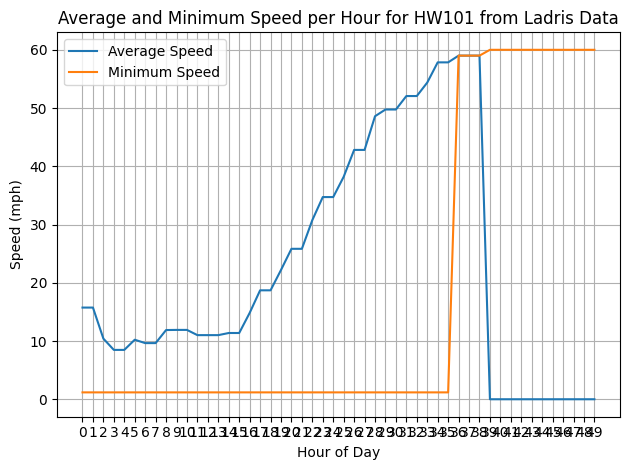

In [64]:
### Plot hour_avg as a line plot with x axis as hours from 0 to 24 and y axis as average speed also plot hour_min as a line plot with x axis as hours from 0 to 24 and y axis as minimum speed
plt.plot(range(50), hw101_hour_avg, label='Average Speed')
plt.plot(range(50), hw101_hour_min, label='Minimum Speed')
plt.title('Average and Minimum Speed per Hour for HW101 from Ladris Data')
plt.xlabel('Hour of Day')
plt.ylabel('Speed (mph)')
plt.xticks(range(50))
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [65]:
print(len(hw116_hour_avg), len(hw101_hour_avg), len(hw12_hour_avg))

50 50 50


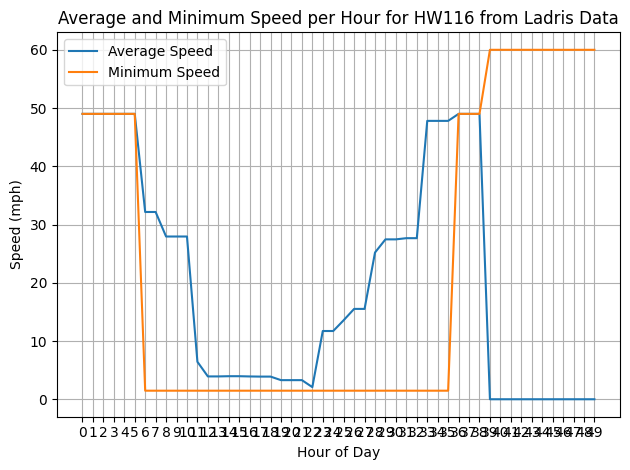

In [67]:
### Plot hour_avg as a line plot with x axis as hours from 0 to 24 and y axis as average speed also plot hour_min as a line plot with x axis as hours from 0 to 24 and y axis as minimum speed
plt.plot(range(50), hw116_hour_avg, label='Average Speed')
plt.plot(range(50), hw116_hour_min, label='Minimum Speed')
plt.title('Average and Minimum Speed per Hour for HW116 from Ladris Data')
plt.xlabel('Hour of Day')
plt.ylabel('Speed (mph)')
plt.xticks(range(50))
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

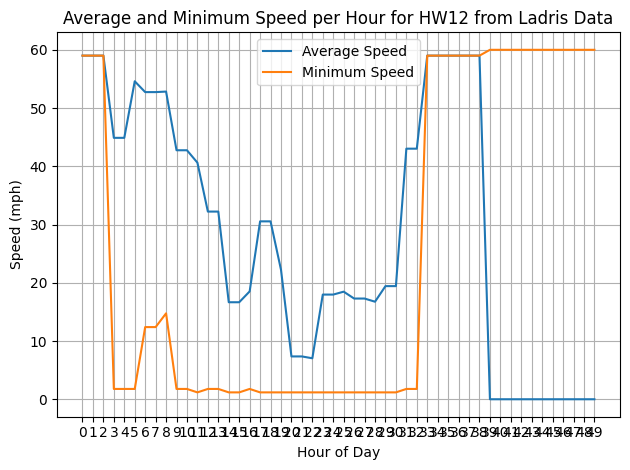

In [69]:
### Plot hour_avg as a line plot with x axis as hours from 0 to 24 and y axis as average speed also plot hour_min as a line plot with x axis as hours from 0 to 24 and y axis as minimum speed
plt.plot(range(50), hw12_hour_avg, label='Average Speed')
plt.plot(range(50), hw12_hour_min, label='Minimum Speed')
plt.title('Average and Minimum Speed per Hour for HW12 from Ladris Data')
plt.xlabel('Hour of Day')
plt.ylabel('Speed (mph)')
plt.xticks(range(50))
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [70]:
total_filtered_data

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time,Distance,Avg_Speed,Date,Hour
0,User37,38.307287,-122.478139,2019-10-26 17:37:00,38.294198,-122.475950,2019-10-26 17:58:00,Hwy 12,Hwy 12,21.0,0.912118,2.606051,2019-10-26,2019-10-26 17:00:00
1,User98,38.319046,-122.485520,2019-10-26 20:25:00,38.302395,-122.475478,2019-10-26 20:35:00,Hwy 12,Hwy 12,10.0,1.272787,7.636719,2019-10-26,2019-10-26 20:00:00
2,User108,38.343465,-122.497494,2019-10-26 01:36:00,38.458950,-122.673962,2019-10-26 01:55:00,Hwy 12,Hwy 12,19.0,12.448713,39.311727,2019-10-26,2019-10-26 01:00:00
3,User108,38.449852,-122.683446,2019-10-26 05:12:00,38.392817,-122.530753,2019-10-26 05:26:00,Hwy 12,Hwy 12,14.0,9.156916,39.243925,2019-10-26,2019-10-26 05:00:00
4,User108,38.305785,-122.477710,2019-10-26 23:14:00,38.355610,-122.502558,2019-10-26 23:32:00,Hwy 12,Hwy 12,18.0,3.696630,12.322099,2019-10-26,2019-10-26 23:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,User2028,38.392002,-122.817728,2019-10-26 03:15:00,38.468563,-122.884547,2019-10-26 03:26:00,Hwy 116,Hwy 116,11.0,6.407988,34.952660,2019-10-26,2019-10-26 03:00:00
872,User2156,38.389170,-122.815711,2019-10-26 00:32:00,38.412086,-122.842662,2019-10-26 00:43:00,Hwy 116,Hwy 116,11.0,2.153280,11.745163,2019-10-26,2019-10-26 00:00:00
873,User2170,38.345782,-122.759535,2019-10-26 21:35:00,38.334367,-122.736961,2019-10-26 23:13:00,Hwy 116,Hwy 116,98.0,1.455552,0.891154,2019-10-26,2019-10-26 21:00:00
874,User2321,38.415091,-122.845280,2019-10-26 23:33:00,38.340804,-122.753055,2019-10-26 23:48:00,Hwy 116,Hwy 116,15.0,7.162274,28.649095,2019-10-26,2019-10-26 23:00:00


In [71]:
### Redwood is 101
### CA 12 is 12
### Gravenstein is 116

### Reduce unique_highways to only 'Hwy 12', 'Hwy 101', and 'Hwy 116'
#unique_highways = ['Hwy 12', 'Hwy 101', 'Hwy 116']

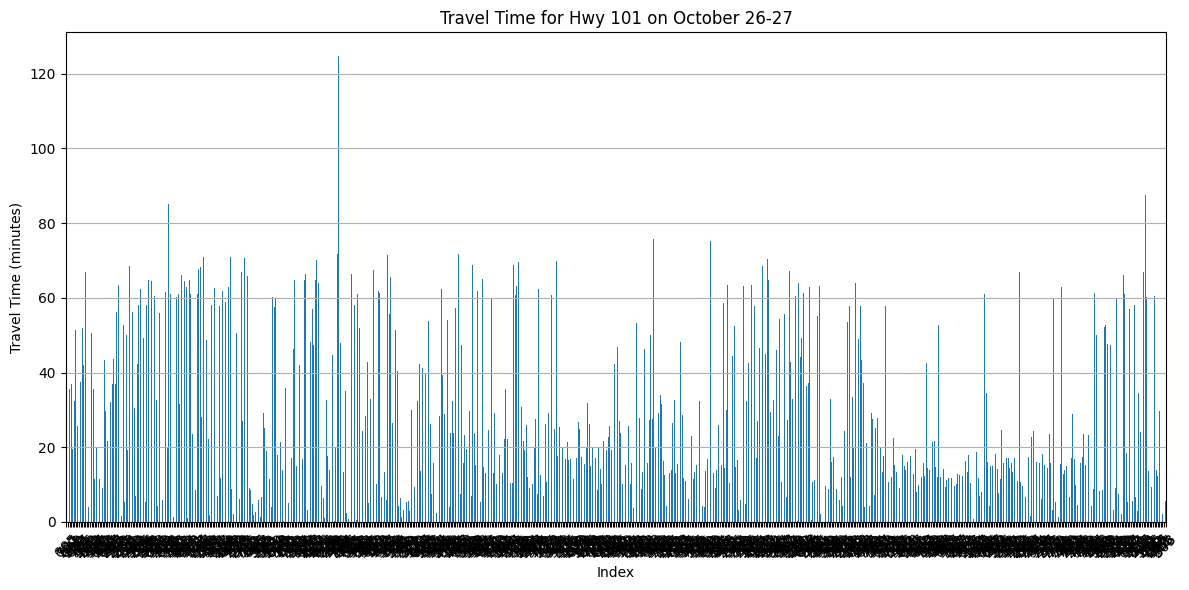

In [72]:

### plot total_filtered_data where Entrance_HWY is 'Hwy 101' sorted by Entrance_TIMESTAMP
kinkade_tt_list = total_filtered_data[total_filtered_data['Entrance_HWY'] == 'Hwy 101'].sort_values(by='Entrance_TIMESTAMP')['Avg_Speed']

### plot bar plot of kinkade_tt_list
kinkade_tt_list.plot(kind='bar', figsize=(12, 6))
plt.title('Travel Time for Hwy 101 on October 26-27')
plt.xlabel('Index')
plt.ylabel('Travel Time (minutes)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()



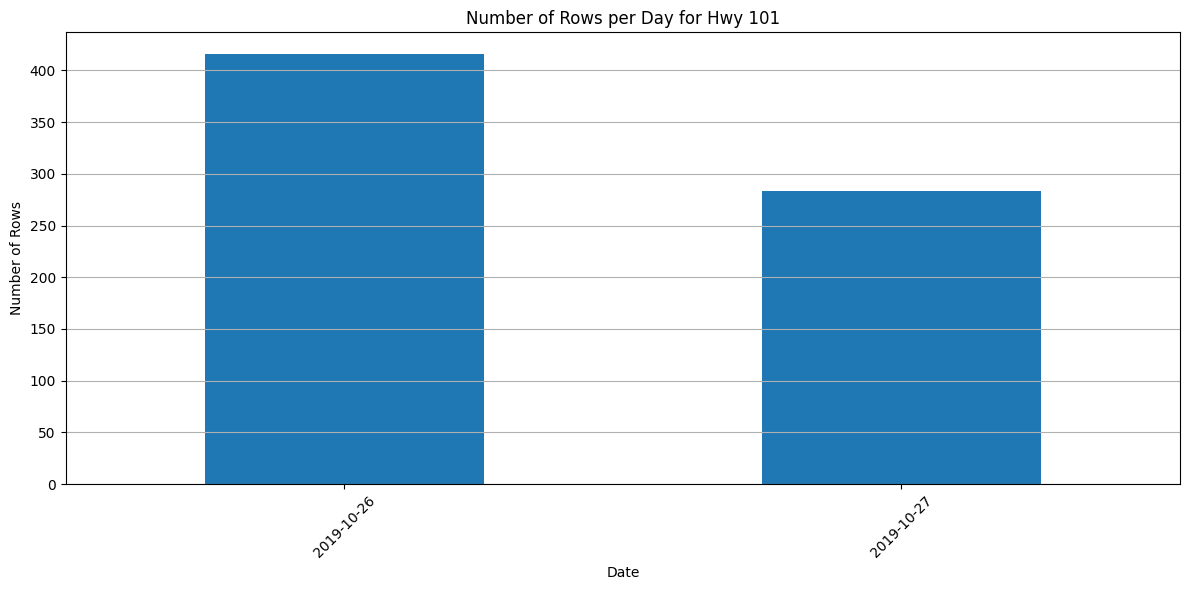

In [73]:
### create a histogram by date for total_filtered_data where Entrance_HWY is 'Hwy 101'
total_filtered_data[total_filtered_data['Entrance_HWY'] == 'Hwy 101']['Entrance_TIMESTAMP'].dt.date.value_counts().sort_index().plot(kind='bar', figsize=(12, 6))
plt.title('Number of Rows per Day for Hwy 101')
plt.xlabel('Date')
plt.ylabel('Number of Rows')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [74]:
### give summary stats for total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101')]['Travel_Time']
hw101_dists = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101')]['Distance'].describe()
hw116_dists = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 116') & (total_filtered_data['Exit_HWY'] == 'Hwy 116')]['Travel_Time'].describe()
hw12_dists = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Exit_HWY'] == 'Hwy 12')]['Travel_Time'].describe()

In [75]:
hw101_dists

count    699.000000
mean      10.834474
std        7.679627
min        0.370975
25%        5.087535
50%        9.767993
75%       14.155400
max       46.780909
Name: Distance, dtype: float64

# Filters to get different collections of data based on distance bins

In [76]:
### get total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101')]['Distance'] that are less than hw101_dists['25%']
#total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['25%'])]

### print total_filtered_data[total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26')] where Entrance_Hwy is 'Hwy 101' and Exit_Hwy is 'Hwy 101'
#total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]


### get total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101')]['Distance'] that are less than hw101_dists['50%'] and greater than hw101_dists['25%']
#total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['max']) & (total_filtered_data['Distance'] >= hw101_dists['75%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]

#total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26') + pd.Timedelta(hours=hour))]

# Now get the average speed per hour for main evacuation Routes

In [77]:
ranges = ['25%', '50%', '75%', 'max', 'all']
### create a list of average speeds for each hour of total_filtered_data[total_filtered_data['Entrance_HWY'] == 'Hwy 101'].sort_values(by='Entrance_TIMESTAMP')['Avg_Speed']
speed_hw101_bins = {}
speed_hw101_avg_list = []

hw101_total_mean = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]['Avg_Speed'].mean()
for hour in range(48):  # 48 hours from Oct 26 00:00 to Oct 27 23:59
    hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26') + pd.Timedelta(hours=hour))]        
    if not hourly_data.empty:
        avg_speed = hourly_data['Avg_Speed'].mean()
    else:
        avg_speed = hw101_total_mean
    speed_hw101_avg_list.append(avg_speed)  
for r in ranges:
    speed_hw101_bins[r] = []    
    if r == '25%':
        #hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26') + pd.Timedelta(hours=hour))]
        ### get hourly_data for distances are less than hw101_dists
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw101_bins[r].append(avg_speed)
    elif r == '50%':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['50%']) & (total_filtered_data['Distance'] >= hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw101_bins[r].append(avg_speed)
    elif r == '75%':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['75%']) & (total_filtered_data['Distance'] >= hw101_dists['50%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw101_bins[r].append(avg_speed)
    elif r == 'max':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['max']) & (total_filtered_data['Distance'] >= hw101_dists['75%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw101_bins[r].append(avg_speed)
    elif r == 'all':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw101_bins[r].append(avg_speed)


### do the same for Hwy 116
speed_hw116_bins = {}
speed_hw116_avg_list = []
hw116_total_mean = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 116') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]['Avg_Speed'].mean()
for hour in range(48):  # 48 hours from Oct 26 00:00 to Oct 27 23:59
    hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 116') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26') + pd.Timedelta(hours=hour))]
    if not hourly_data.empty:
        avg_speed = hourly_data['Avg_Speed'].mean()
    else:
        avg_speed = hw116_total_mean
    speed_hw116_avg_list.append(avg_speed)    
#speed_hw116_avg_list
for r in ranges:
    speed_hw116_bins[r] = []    
    if r == '25%':
        #hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26') + pd.Timedelta(hours=hour))]
        ### get hourly_data for distances are less than hw101_dists
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 116') & (total_filtered_data['Exit_HWY'] == 'Hwy 116') & (total_filtered_data['Distance'] < hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw116_bins[r].append(avg_speed)
    elif r == '50%':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 116') & (total_filtered_data['Exit_HWY'] == 'Hwy 116') & (total_filtered_data['Distance'] < hw101_dists['50%']) & (total_filtered_data['Distance'] >= hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw116_bins[r].append(avg_speed)
    elif r == '75%':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 116') & (total_filtered_data['Exit_HWY'] == 'Hwy 116') & (total_filtered_data['Distance'] < hw101_dists['75%']) & (total_filtered_data['Distance'] >= hw101_dists['50%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw116_bins[r].append(avg_speed)
    elif r == 'max':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 116') & (total_filtered_data['Exit_HWY'] == 'Hwy 116') & (total_filtered_data['Distance'] < hw101_dists['max']) & (total_filtered_data['Distance'] >= hw101_dists['75%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw116_bins[r].append(avg_speed)
    elif r == 'all':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 116') & (total_filtered_data['Exit_HWY'] == 'Hwy 116') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw116_bins[r].append(avg_speed)

### do the same for Hwy 12
speed_hw12_bins = {}
speed_hw12_avg_list = []
hw12_total_mean = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]['Avg_Speed'].mean()
for hour in range(48):  # 48 hours from Oct 26 00:00 to Oct 27 23:59
    hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26') + pd.Timedelta(hours=hour))]
    if not hourly_data.empty:
        avg_speed = hourly_data['Avg_Speed'].mean()
    else:
        avg_speed = hw12_total_mean
    speed_hw12_avg_list.append(avg_speed)    
for r in ranges:
    speed_hw12_bins[r] = []    
    if r == '25%':
        #hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26') + pd.Timedelta(hours=hour))]
        ### get hourly_data for distances are less than hw101_dists
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Exit_HWY'] == 'Hwy 12') & (total_filtered_data['Distance'] < hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw12_bins[r].append(avg_speed)
    elif r == '50%':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Exit_HWY'] == 'Hwy 12') & (total_filtered_data['Distance'] < hw101_dists['50%']) & (total_filtered_data['Distance'] >= hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw12_bins[r].append(avg_speed)
    elif r == '75%':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Exit_HWY'] == 'Hwy 12') & (total_filtered_data['Distance'] < hw101_dists['75%']) & (total_filtered_data['Distance'] >= hw101_dists['50%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw12_bins[r].append(avg_speed)
    elif r == 'max':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Exit_HWY'] == 'Hwy 12') & (total_filtered_data['Distance'] < hw101_dists['max']) & (total_filtered_data['Distance'] >= hw101_dists['75%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw12_bins[r].append(avg_speed)
    elif r == 'all':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Exit_HWY'] == 'Hwy 12') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw12_bins[r].append(avg_speed)
#speed_hw12_avg_list

In [78]:
### For 101 25% is under 5 miles, 50% is 5-10 miles, 75% is 10-15 miles, max is 15+ miles
### For 116 25% is under 3 miles, 50% is 3-10 miles, 75% is 5-10 miles, max is 5+ miles
### For 12 25% is under 3 miles, 50% is 6-7 miles, 75% is 10+ miles, max is 10+ miles
print(len(speed_hw12_bins['25%']))
speed_hw12_bins['25%'][0]



1


,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time,Distance,Avg_Speed,Date,Hour
15,User444,38.431742,-122.706792,2019-10-26 00:35:00,38.45865,-122.674648,2019-10-26 00:46:00,Hwy 12,Hwy 12,11.0,2.546007,13.887308,2019-10-26,2019-10-26
114,User2381,38.431184,-122.708723,2019-10-26 00:34:00,38.45822,-122.675421,2019-10-26 00:45:00,Hwy 12,Hwy 12,11.0,2.595590,14.157761,2019-10-26,2019-10-26


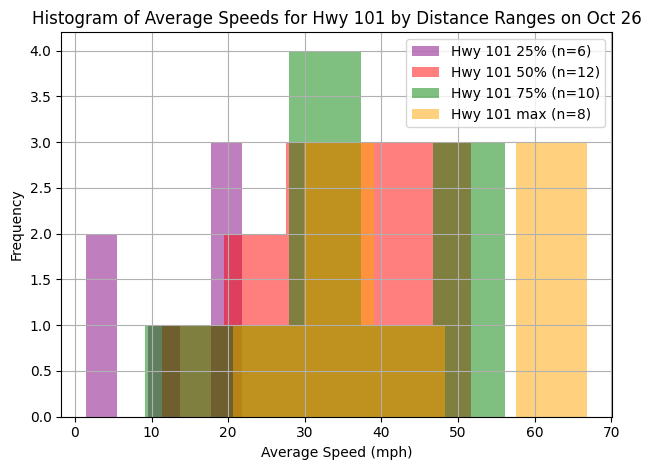

In [79]:
### plot a histogram for each speed_hw101_bins[r][0]['Avg_Speed'] for r in ranges on the same plot with different colors and a legend
for r in ranges:
    #if r == 'all':
    #    plt.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.5, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='blue')
    if r == 'max':
        plt.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.5, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='orange')
    elif r == '75%':
        plt.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.5, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='green')
    elif r == '50%':
        plt.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.5, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='red')
    elif r == '25%':
        plt.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.5, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='purple')
plt.title('Histogram of Average Speeds for Hwy 101 by Distance Ranges on Oct 26')
plt.xlabel('Average Speed (mph)')
plt.ylabel('Frequency')
plt.legend()
plt.grid()  
plt.tight_layout()
plt.show()

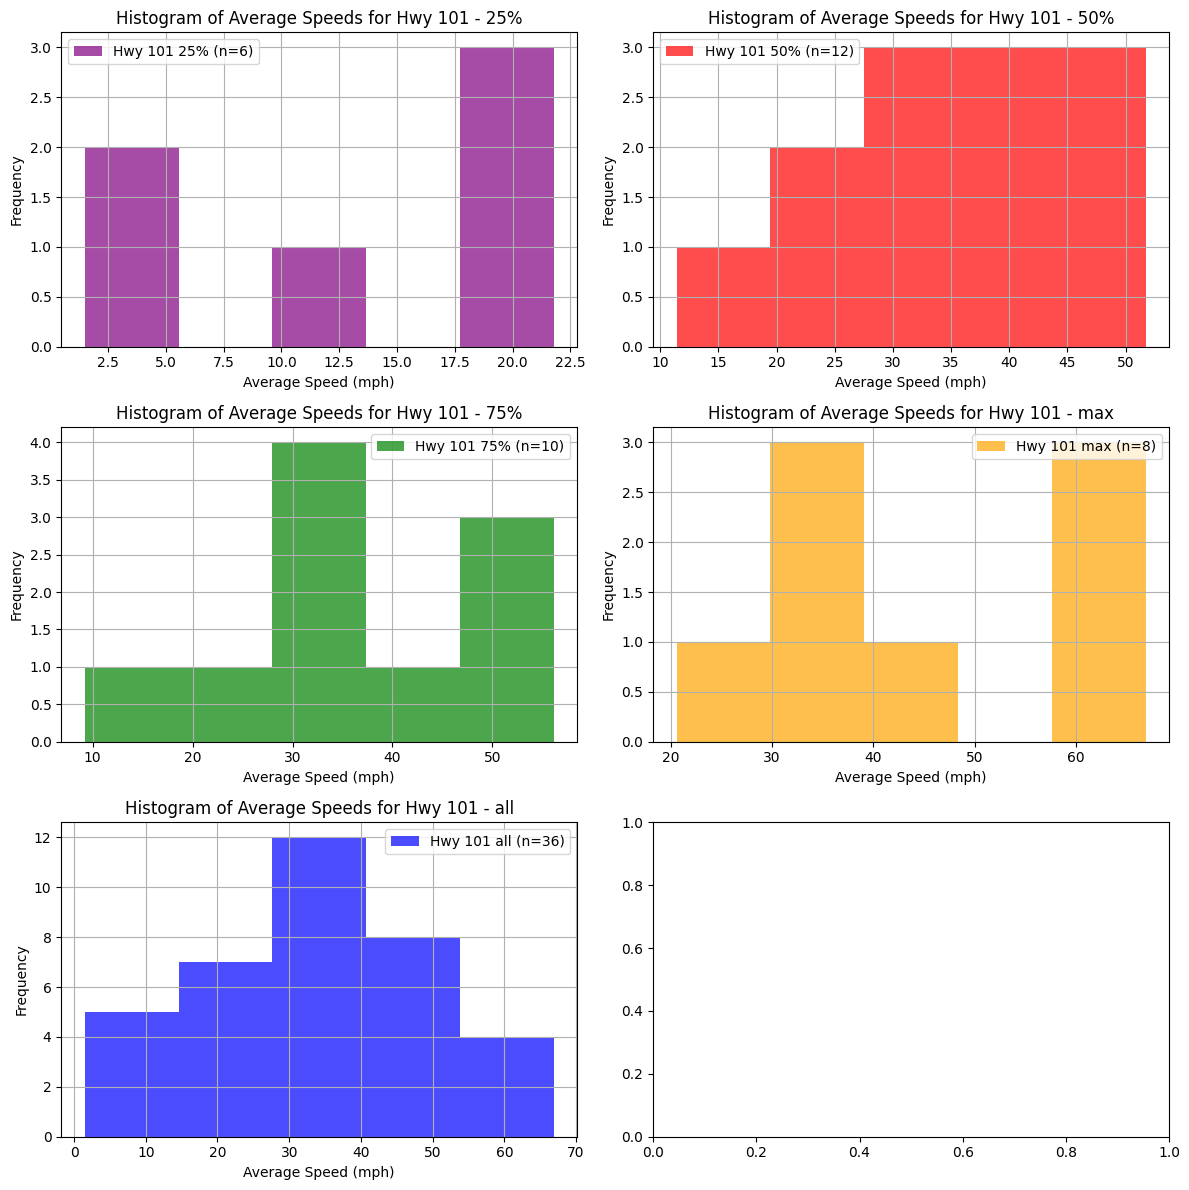

In [80]:
### plot a histogram for each speed_hw101_bins[r][0]['Avg_Speed'] for r in ranges on different subplots in a grid
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
for i, r in enumerate(ranges):  
    ax = axs[i // 2, i % 2]
    if r == 'all':
        ax.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='blue')
    elif r == 'max':
        ax.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='orange')
    elif r == '75%':
        ax.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='green')
    elif r == '50%':
        ax.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='red')
    elif r == '25%':
        ax.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='purple')
    ax.set_title(f'Histogram of Average Speeds for Hwy 101 - {r}')
    ax.set_xlabel('Average Speed (mph)')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid()
plt.tight_layout()
plt.show()


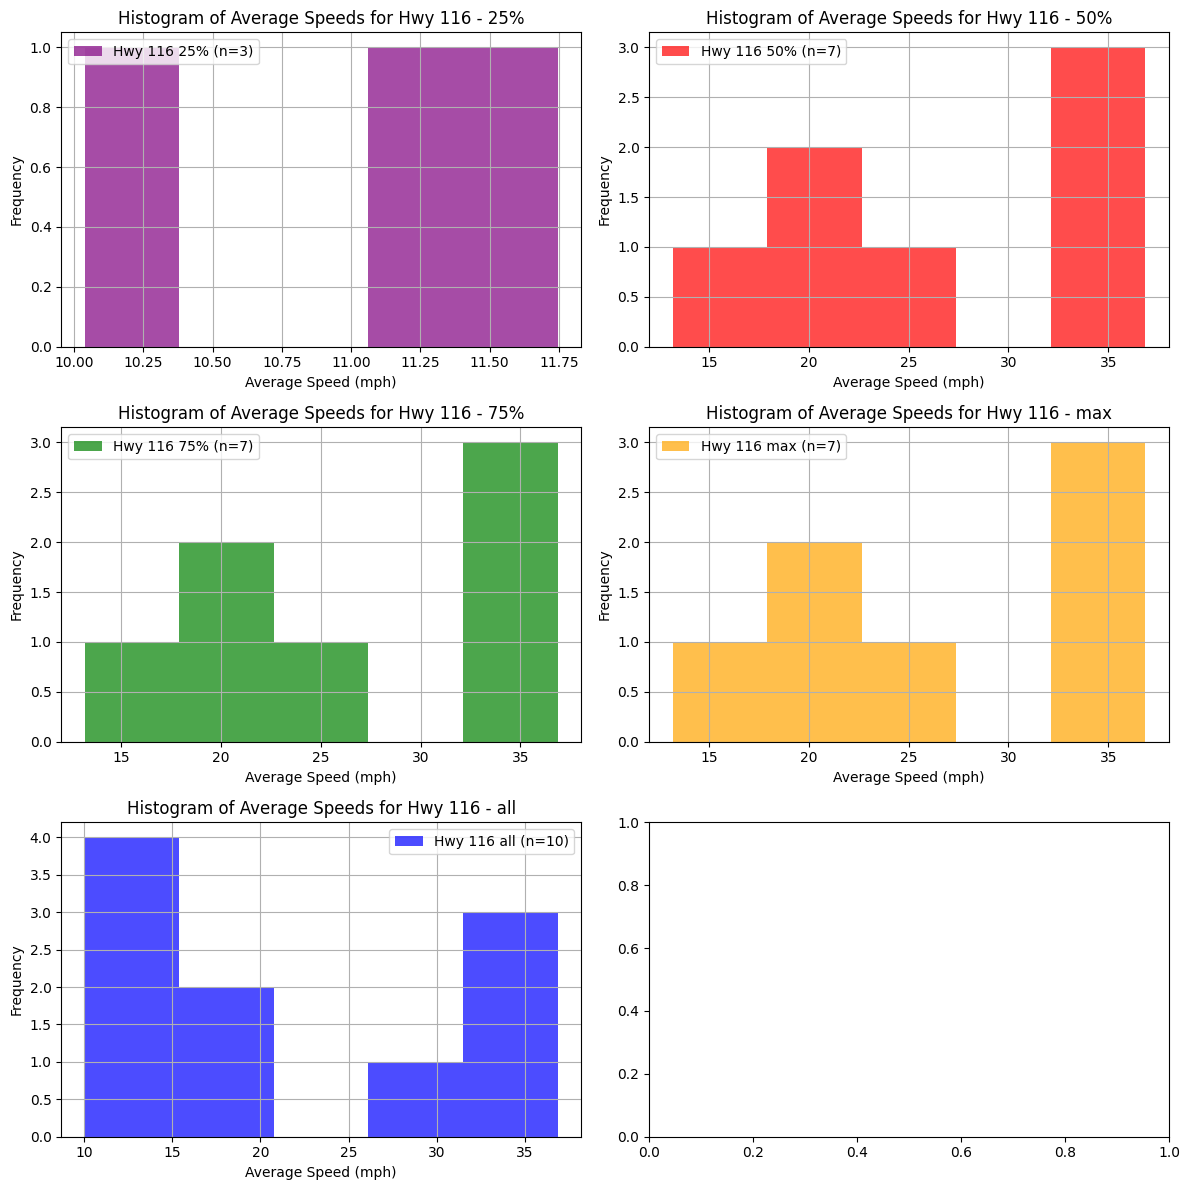

In [81]:
### plot a histogram for each speed_hw101_bins[r][0]['Avg_Speed'] for r in ranges on different subplots in a grid
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
for i, r in enumerate(ranges):  
    ax = axs[i // 2, i % 2]
    if r == 'all':
        ax.hist(speed_hw116_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 116 {r} (n={len(speed_hw116_bins[r][0])})', color='blue')
    elif r == 'max':
        ax.hist(speed_hw116_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 116 {r} (n={len(speed_hw116_bins[r][0])})', color='orange')
    elif r == '75%':
        ax.hist(speed_hw116_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 116 {r} (n={len(speed_hw116_bins[r][0])})', color='green')
    elif r == '50%':
        ax.hist(speed_hw116_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 116 {r} (n={len(speed_hw116_bins[r][0])})', color='red')
    elif r == '25%':
        ax.hist(speed_hw116_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 116 {r} (n={len(speed_hw116_bins[r][0])})', color='purple')
    ax.set_title(f'Histogram of Average Speeds for Hwy 116 - {r}')
    ax.set_xlabel('Average Speed (mph)')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid()
plt.tight_layout()
plt.show()

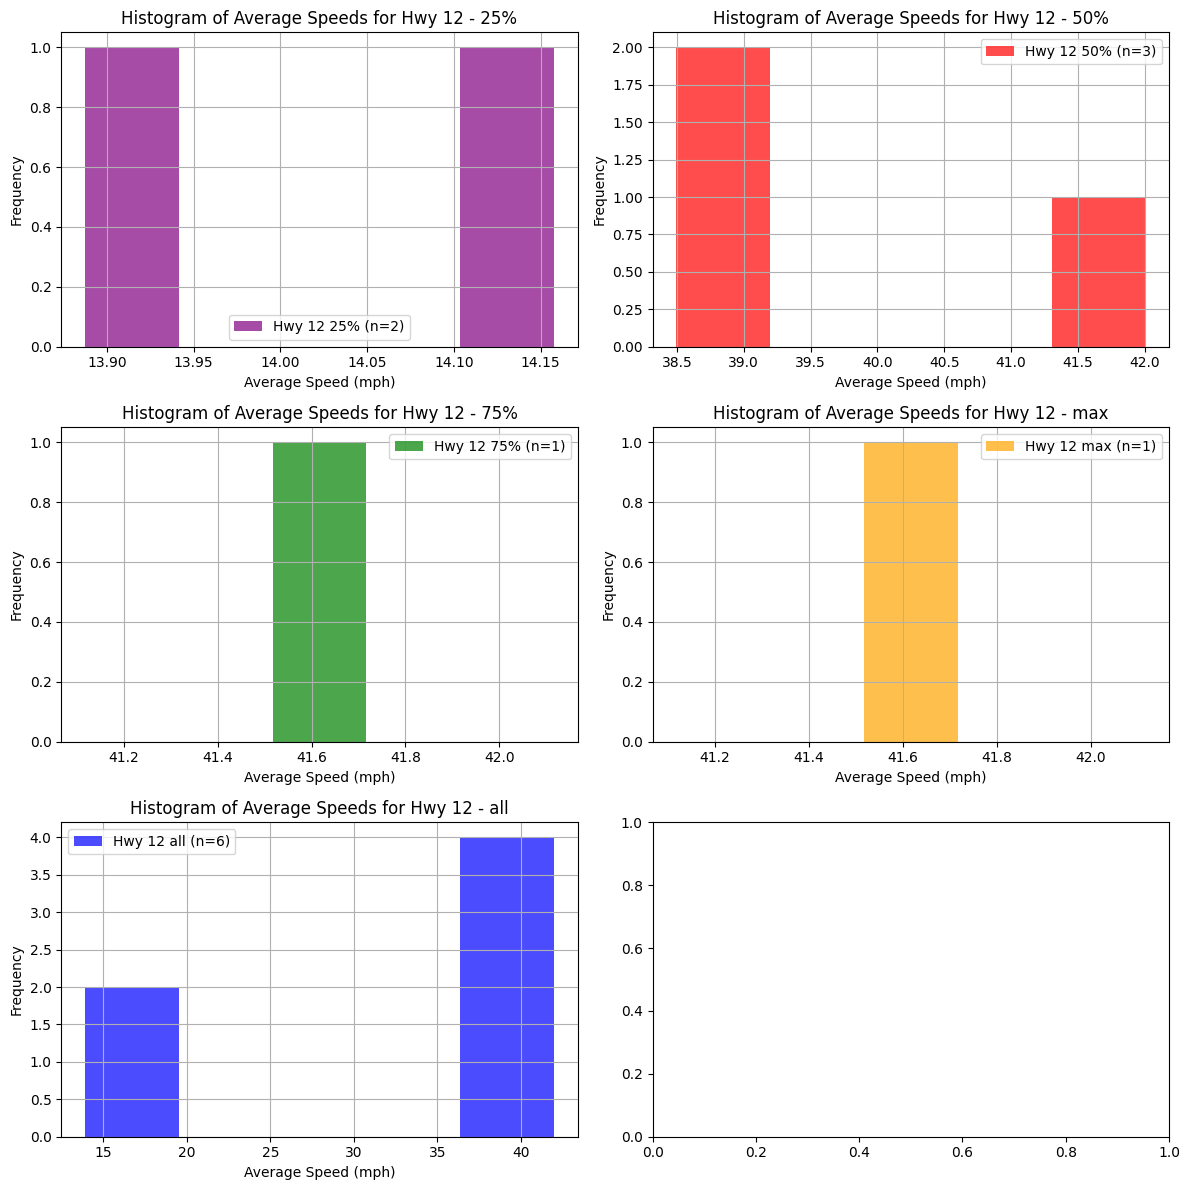

In [82]:
### plot a histogram for each speed_hw101_bins[r][0]['Avg_Speed'] for r in ranges on different subplots in a grid
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
for i, r in enumerate(ranges):  
    ax = axs[i // 2, i % 2]
    if r == 'all':
        ax.hist(speed_hw12_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 12 {r} (n={len(speed_hw12_bins[r][0])})', color='blue')
    elif r == 'max':
        ax.hist(speed_hw12_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 12 {r} (n={len(speed_hw12_bins[r][0])})', color='orange')
    elif r == '75%':
        ax.hist(speed_hw12_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 12 {r} (n={len(speed_hw12_bins[r][0])})', color='green')
    elif r == '50%':
        ax.hist(speed_hw12_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 12 {r} (n={len(speed_hw12_bins[r][0])})', color='red')
    elif r == '25%':
        ax.hist(speed_hw12_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 12 {r} (n={len(speed_hw12_bins[r][0])})', color='purple')
    ax.set_title(f'Histogram of Average Speeds for Hwy 12 - {r}')
    ax.set_xlabel('Average Speed (mph)')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid()
plt.tight_layout()
plt.show()

In [83]:
speed_hw116_bins['75%'][0]

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time,Distance,Avg_Speed,Date,Hour
823,User308,38.405692,-122.837126,2019-10-26 00:48:00,38.352220,-122.765200,2019-10-26 01:00:00,Hwy 116,Hwy 116,12.0,5.369064,26.845322,2019-10-26,2019-10-26
825,User324,38.425476,-122.848241,2019-10-26 00:31:00,38.472983,-123.016426,2019-10-26 01:15:00,Hwy 116,Hwy 116,44.0,9.674525,13.192534,2019-10-26,2019-10-26
833,User632,38.437149,-122.857682,2019-10-26 00:13:00,38.478219,-122.997329,2019-10-26 00:40:00,Hwy 116,Hwy 116,27.0,8.070864,17.935254,2019-10-26,2019-10-26
838,User889,38.452212,-122.868497,2019-10-26 00:09:00,38.365352,-122.781765,2019-10-26 00:32:00,Hwy 116,Hwy 116,23.0,7.620221,19.878838,2019-10-26,2019-10-26
840,User891,38.330934,-122.710440,2019-10-26 00:38:00,38.379428,-122.799103,2019-10-26 00:48:00,Hwy 116,Hwy 116,10.0,5.856962,35.141774,2019-10-26,2019-10-26
857,User1615,38.331491,-122.714259,2019-10-26 00:13:00,38.389084,-122.815067,2019-10-26 00:24:00,Hwy 116,Hwy 116,11.0,6.757457,36.858857,2019-10-26,2019-10-26
860,User1683,38.442041,-122.860987,2019-10-26 00:05:00,38.499162,-122.972438,2019-10-26 00:17:00,Hwy 116,Hwy 116,12.0,7.205863,36.029314,2019-10-26,2019-10-26


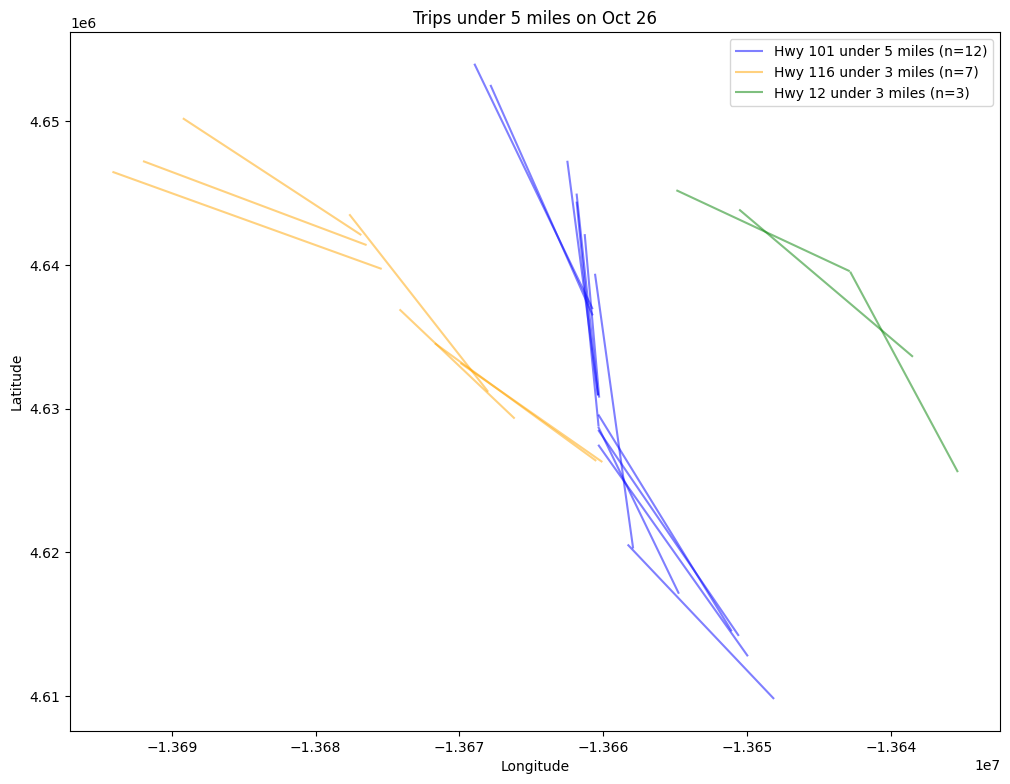

In [84]:
### create a geodataframe linestring for speed_hw101_bins['25%'][0] based on Entrance_Lat, Entrance_Lon, Exit_Lat, Exit_Lon
import geopandas as gpd
from shapely.geometry import LineString
import contextily as ctx
import matplotlib.pyplot as plt

perc = '50%'

gdf_hw101_25 = gpd.GeoDataFrame(speed_hw101_bins[perc][0], geometry=gpd.points_from_xy(speed_hw101_bins[perc][0]['Entrance_LON'], speed_hw101_bins[perc][0]['Entrance_LAT']))
gdf_hw101_25['Exit_Point'] = gpd.points_from_xy(speed_hw101_bins[perc][0]['Exit_LON'], speed_hw101_bins[perc][0]['Exit_LAT'])
gdf_hw101_25['geometry'] = gdf_hw101_25.apply(lambda row: LineString([row['geometry'], row['Exit_Point']]), axis=1)
gdf_hw101_25 = gdf_hw101_25.drop(columns=['Exit_Point'])
gdf_hw101_25.set_crs(epsg=4326, inplace=True)
gdf_hw116_25 = gpd.GeoDataFrame(speed_hw116_bins[perc][0], geometry=gpd.points_from_xy(speed_hw116_bins[perc][0]['Entrance_LON'], speed_hw116_bins[perc][0]['Entrance_LAT']))
gdf_hw116_25['Exit_Point'] = gpd.points_from_xy(speed_hw116_bins[perc][0]['Exit_LON'], speed_hw116_bins[perc][0]['Exit_LAT'])
gdf_hw116_25['geometry'] = gdf_hw116_25.apply(lambda row: LineString([row['geometry'], row['Exit_Point']]), axis=1)
gdf_hw116_25 = gdf_hw116_25.drop(columns=['Exit_Point'])
gdf_hw116_25.set_crs(epsg=4326, inplace=True)
gdf_hw12_25 = gpd.GeoDataFrame(speed_hw12_bins[perc][0], geometry=gpd.points_from_xy(speed_hw12_bins[perc][0]['Entrance_LON'], speed_hw12_bins[perc][0]['Entrance_LAT']))
gdf_hw12_25['Exit_Point'] = gpd.points_from_xy(speed_hw12_bins[perc][0]['Exit_LON'], speed_hw12_bins[perc][0]['Exit_LAT'])        
gdf_hw12_25['geometry'] = gdf_hw12_25.apply(lambda row: LineString([row['geometry'], row['Exit_Point']]), axis=1)
gdf_hw12_25 = gdf_hw12_25.drop(columns=['Exit_Point'])
gdf_hw12_25.set_crs(epsg=4326, inplace=True)
### plot plot all the gdf on the same plot with different colors and a legend
fig, ax = plt.subplots(figsize=(12, 12))
gdf_hw101_25.to_crs(epsg=3857).plot(ax=ax, color='blue', alpha=0.5, label=f'Hwy 101 under 5 miles (n={len(gdf_hw101_25)})')
gdf_hw116_25.to_crs(epsg=3857).plot(ax=ax, color='orange', alpha=0.5, label=f'Hwy 116 under 3 miles (n={len(gdf_hw116_25)})')
gdf_hw12_25.to_crs(epsg=3857).plot(ax=ax, color='green', alpha=0.5, label=f'Hwy 12 under 3 miles (n={len(gdf_hw12_25)})')
ax.legend()
plt.title('Trips under 5 miles on Oct 26')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [85]:
print(len(gdf_hw101_25), len(gdf_hw116_25), len(gdf_hw12_25))

12 7 3


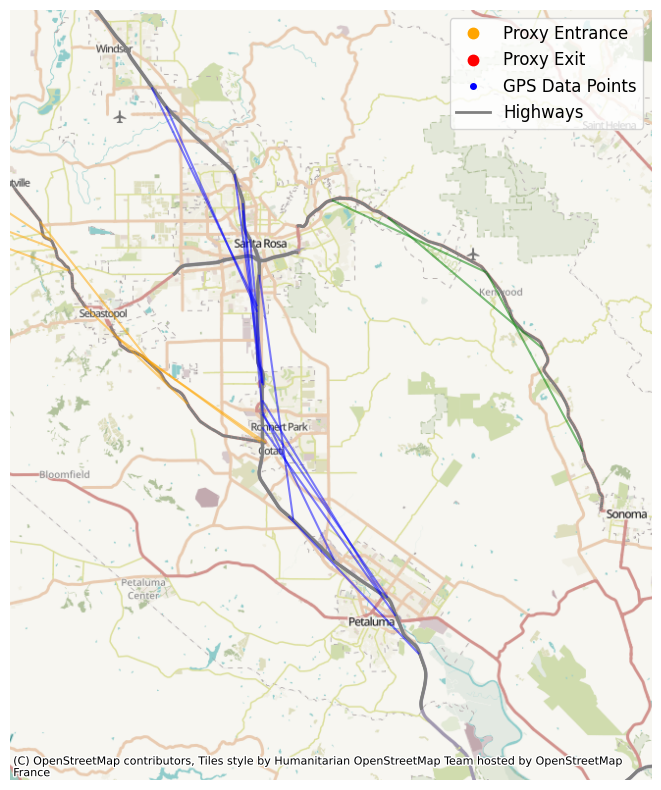

In [86]:
### adjust the code below to overlay gdf_hw101_25 on top of a map of highways in the area
import geopandas as gpd
import contextily as cx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1,figsize=(10, 10),dpi=100)
highways = gpd.read_file('Highways.shp')
highways = highways.to_crs(epsg=3857)
highways.plot(ax=ax, color='gray', linewidth=2, zorder=1)

#gdf_hw101_25.to_crs(epsg=3857).plot(ax=ax,color='b',markersize=10, zorder=2)
gdf_hw101_25.to_crs(epsg=3857).plot(ax=ax, color='blue', alpha=0.5, label=f'Hwy 101 under 5 miles (n={len(gdf_hw101_25)})')
gdf_hw116_25.to_crs(epsg=3857).plot(ax=ax, color='orange', alpha=0.5, label=f'Hwy 116 under 3 miles (n={len(gdf_hw116_25)})')
gdf_hw12_25.to_crs(epsg=3857).plot(ax=ax, color='green', alpha=0.5, label=f'Hwy 12 under 3 miles (n={len(gdf_hw12_25)})')
#gdf_hw101_25.to_crs(epsg=3857).loc[[exit_index]].plot(ax=ax,color='r',markersize=50, zorder=3)  

legend_elements = [Line2D([0], [0], marker='.', color='orange', lw=0, markersize=15, label='Proxy Entrance'),
                   Line2D([0], [0], marker='.', color='r', lw=0, markersize=15, label='Proxy Exit'),
                   Line2D([0], [0], marker='.', color='b', lw=0, markersize=8, label='GPS Data Points'),
                   Line2D([0], [0], marker='.', color='gray', lw=2, markersize=0, markerfacecolor='k', label='Highways'),
                  ]
ax.legend(handles=legend_elements,fontsize=12)

ax.set_ylim(4600000, 4660000)
ax.set_xlim(-13680000, -13630000)
ax.axis('off')

cx.add_basemap(ax)

In [246]:
### create a geodataframe that is the 25% for each highway
hw101_25_gdf = gpd.GeoDataFrame(speed_hw101_bins['25%'][0], geometry=gpd.points_from_xy(speed_hw101_bins['25%'][0]['Entrance_LON'], speed_hw101_bins['25%'][0]['Entrance_LAT']), crs='EPSG:4326')
hw116_25_gdf = gpd.GeoDataFrame(speed_hw116_bins['25%'][0], geometry=gpd.points_from_xy(speed_hw116_bins['25%'][0]['Entrance_LON'], speed_hw116_bins['25%'][0]['Entrance_LAT']), crs='EPSG:4326')
hw12_25_gdf = gpd.GeoDataFrame(speed_hw12_bins['25%'][0], geometry=gpd.points_from_xy(speed_hw12_bins['25%'][0]['Entrance_LON'], speed_hw12_bins['25%'][0]['Entrance_LAT']), crs='EPSG:4326')

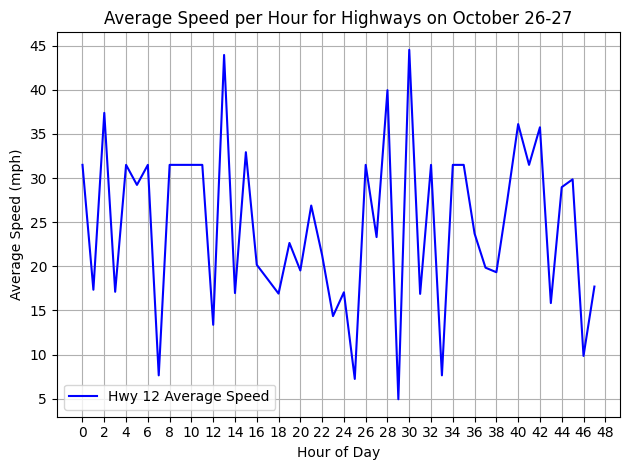

In [88]:
### Plot speed_hw12_avg_list as a line graph
plt.plot(range(48), speed_hw12_avg_list, label='Hwy 12 Average Speed', color='blue')
#plt.plot(range(48), speed_hw116_avg_list, label='Hwy 116 Average Speed', color='orange')
#plt.plot(range(48), speed_hw101_avg_list, label='Hwy 101 Average Speed', color='green')
plt.title('Average Speed per Hour for Highways on October 26-27')
plt.xlabel('Hour of Day')
plt.ylabel('Average Speed (mph)')
plt.xticks(range(0, 49, 2))
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

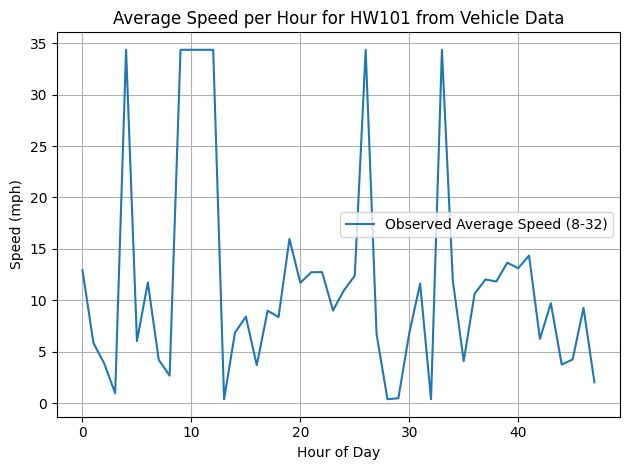

In [89]:
plt.plot(range(48), speed_hw101_avg_list, label='Observed Average Speed (8-32)')
#plt.plot(range(25), hw101_hour_avg, label='Simulated Average Speed')
plt.title('Average Speed per Hour for HW101 from Vehicle Data')
plt.xlabel('Hour of Day')
plt.ylabel('Speed (mph)')
#plt.xticks(range(0, 24, 2)) # Show x-ticks every 2 hours
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

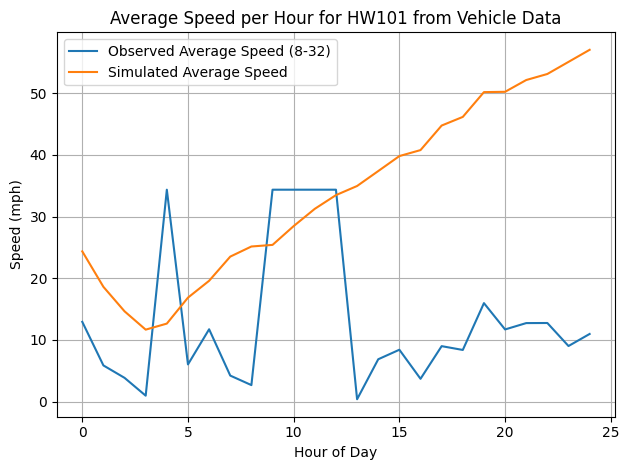

In [90]:
### Plot hour_avg as a line plot with x axis as hours from 0 to 48 and y axis as average speed
#plt.plot(range(25), speed_hw101_avg_list[:25], label='Average Speed')
### plot hour 8 to hour 32 of speed_hw101_avg_list
## 4-29 pretty close
plt.plot(range(25), speed_hw101_avg_list[0:25], label='Observed Average Speed (8-32)')
plt.plot(range(25), hw101_hour_avg, label='Simulated Average Speed')
plt.title('Average Speed per Hour for HW101 from Vehicle Data')
plt.xlabel('Hour of Day')
plt.ylabel('Speed (mph)')
#plt.xticks(range(0, 24, 2)) # Show x-ticks every 2 hours
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

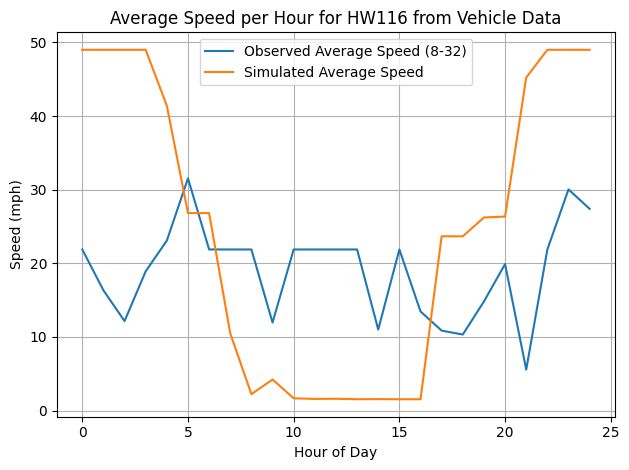

In [92]:
plt.plot(range(25), speed_hw116_avg_list[0:25], label='Observed Average Speed (8-32)')
plt.plot(range(25), hw116_hour_avg, label='Simulated Average Speed')
plt.title('Average Speed per Hour for HW116 from Vehicle Data')
plt.xlabel('Hour of Day')
plt.ylabel('Speed (mph)')
#plt.xticks(range(0, 24, 2)) # Show x-ticks every 2 hours
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

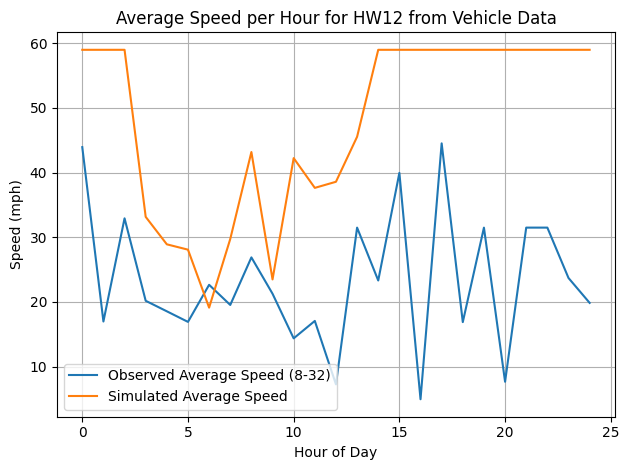

In [93]:
plt.plot(range(25), speed_hw12_avg_list[13:38], label='Observed Average Speed (8-32)')
plt.plot(range(25), hw12_hour_avg, label='Simulated Average Speed')
plt.title('Average Speed per Hour for HW12 from Vehicle Data')
plt.xlabel('Hour of Day')
plt.ylabel('Speed (mph)')
#plt.xticks(range(0, 24, 2)) # Show x-ticks every 2 hours
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [87]:
### create a list of average speeds for each hour of total_filtered_data[total_filtered_data['Entrance_HWY'] == 'Hwy 101'].sort_values(by='Entrance_TIMESTAMP')['Avg_Speed']
#speed_hw116_avg_list = []
#for hour in range(48):  # 48 hours from Oct 26 00:00 to Oct 27 23:59
#    hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26') + pd.Timedelta(hours=hour))]
#    if not hourly_data.empty:
#        avg_speed = hourly_data['Avg_Speed'].mean()
#    else:
#        avg_speed = 0
#    speed_hw101_avg_list.append(avg_speed)    
#speed_hw101_avg_list

In [88]:
### measure the error of speed_hw101_avg_list and hw101_ladris_speed_congestion for the first 24 elements
from sklearn.metrics import mean_squared_error
import numpy as np  

lower_segids = []
for segid in hw101_ladris_speed_congestion.keys():
    sim_speeds = [time[1] for time in hw101_ladris_speed_congestion[segid][:24]]
    if len(sim_speeds) == 24:
        mse = mean_squared_error(speed_hw101_avg_list[:24], sim_speeds)
        rmse = np.sqrt(mse)
        #print(f"Segment ID: {segid}, RMSE: {rmse}")
        if rmse < 30:
            lower_segids.append(segid)
print(f"Number of segments with RMSE < 30: {len(lower_segids)}")






Number of segments with RMSE < 30: 37


In [89]:
### compute the average rmse for all segments in hw101_ladris_speed_congestion
total_rmse = 0
count = 0
for segid in hw101_ladris_speed_congestion.keys():
    sim_speeds = [time[1] for time in hw101_ladris_speed_congestion[segid][:24]]
    if len(sim_speeds) == 24:
        mse = mean_squared_error(speed_hw101_avg_list[:24], sim_speeds)
        rmse = np.sqrt(mse)
        total_rmse += rmse
        count += 1
average_rmse = total_rmse / count
print(f"Average RMSE for HW101 segments: {average_rmse}")



Average RMSE for HW101 segments: 24.6445589038765


In [90]:
print(len(speed_hw116_avg_list))

48


In [91]:
### compute the average rmse for all segments in hw116_ladris_speed_congestion
total_rmse = 0
count = 0
for segid in hw116_ladris_speed_congestion.keys():
    sim_speeds = [time[1] for time in hw116_ladris_speed_congestion[segid][:24]]
    if len(sim_speeds) == 24:
        mse = mean_squared_error(speed_hw116_avg_list[:24], sim_speeds)
        rmse = np.sqrt(mse)
        total_rmse += rmse
        count += 1
average_rmse = total_rmse / count
print(f"Average RMSE for HW116 segments: {average_rmse}")



Average RMSE for HW116 segments: 22.70540163134217


In [92]:
### compute the average rmse for all segments in hw12_ladris_speed_congestion
total_rmse = 0
count = 0
for segid in hw12_ladris_speed_congestion.keys():
    sim_speeds = [time[1] for time in hw12_ladris_speed_congestion[segid][:24]]
    if len(sim_speeds) == 24:
        mse = mean_squared_error(speed_hw12_avg_list[:24], sim_speeds)
        rmse = np.sqrt(mse)
        total_rmse += rmse
        count += 1
average_rmse = total_rmse / count
print(f"Average RMSE for HW12 segments: {average_rmse}")

Average RMSE for HW12 segments: 27.040584583280836


In [93]:
### Get fleet lat long
import xml.etree.ElementTree as ET

### read segment id's from ../lhc_samples/data/fleet/segments.xml
tree = ET.parse('fleet_kincadeFire/834602066/segments.xml')
root = tree.getroot()

fleet_segment_dict = {}
fleet_potential_dict = {}
fleet_segment_roadNames = {}
for child in root:
    fleet_segment_dict[child.find('ID').text] = child.find('Link_ID').text
    lanes = int(child.find('Number_of_Lanes').text)
    speed = int(child.find('Freeflow_Speed').text)

    fleet_potential_dict[child.find('ID').text] = lanes * speed

### read ../lhcsamples/data/fleet/links.xml
tree = ET.parse('fleet_kincadeFire/834602066/links.xml')
root = tree.getroot()

fleet_link_dict = {}
fleet_name_dict = {}
for child in root:
    fleet_link_dict[child.find('ID').text] = [child.find('ANode').text, child.find('BNode').text]    
    fleet_name_dict[child.find('ID').text] = child.find('Name').text
    fleet_segment_roadNames[child.find('ID').text] = child.find('Name').text

### read ../lhcsamples/data/fleet/nodes.xml and get lat long for BNode of each fleet_link_dict
tree = ET.parse('fleet_kincadeFire/834602066/nodes.xml')
root = tree.getroot()

fleet_node_dict = {}
for child in root:
    fleet_node_dict[child.find('ID').text] = [child.find('Latitude').text, child.find('Longitude').text]

fleet_lat_long_dict = {}
### for each segment in fleet_segment_dict, get the link_id, from fleet_link_dict get the BNode, from fleet_node_dict get the lat long
for segment in fleet_segment_dict:
    link_id = fleet_segment_dict[segment]
    anode = fleet_link_dict[link_id][0]
    bnode = fleet_link_dict[link_id][1]
    lat_long = [fleet_node_dict[anode], fleet_node_dict[bnode]]
    fleet_lat_long_dict[int(segment)] = [[float(lat_long[0][1]), float(lat_long[0][0])],[float(lat_long[1][1]), float(lat_long[1][0])]]

NameError: name 'fleet_speed_hw101_avg' is not defined

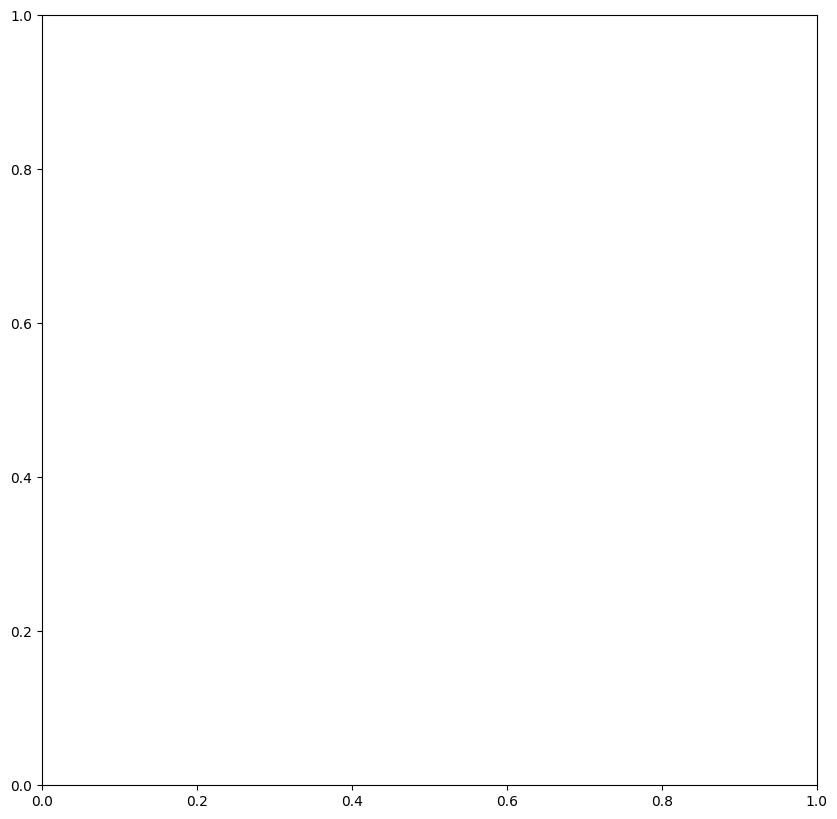

In [ ]:
### plot fleet_speed_hw101_avg.keys() on a map using fleet_lat_long_dict Make all segments gray except for lowerr_segids which should be red
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import LineString
import contextily as ctx
fig, ax = plt.subplots(figsize=(10, 10))
for seg_id in fleet_speed_hw101_avg.keys():
    if int(seg_id) in fleet_lat_long_dict:
        coords = fleet_lat_long_dict[int(seg_id)]
        line = LineString(coords)
        if seg_id in lowerr_segids:
            ax.plot(*line.xy, color='red', linewidth=2, alpha=0.7)
        else:
            ax.plot(*line.xy, color='gray', linewidth=1, alpha=0.5)
# Set the extent
ax.set_xlim(-123.1, -122.3)
ax.set_ylim(38.0, 38.8)
# Add a basemap
plt.title('Fleet Segments with Low RMSE in Red')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()